<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex05_GLM_model_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 05

Exercise 05 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Contents

This exercise covers **model diagnostics** (post-hoc analysis) for GLMs: how to assess whether a fitted model is adequate and how to identify problems in the systematic component, the link function, or individual observations.

1. [Theory: Residuals in GLM](#1-theory-residuals-in-glm)
   - 1.1 [From IRLS to the Hat Matrix](#11-from-irls-to-the-hat-matrix)
   - 1.2 [Types of Residuals](#12-types-of-residuals)
   - 1.3 [Summary Table of Residual Types](#13-summary-table-of-residual-types)
2. [Theory: Diagnostic Plots](#2-theory-diagnostic-plots)
   - 2.1 [Residuals vs Fitted Values](#21-residuals-vs-fitted-values)
   - 2.2 [Q-Q Plot](#22-q-q-plot)
   - 2.3 [Working Responses vs Linear Predictor](#23-working-responses-vs-linear-predictor)
   - 2.4 [Partial Residual Plots](#24-partial-residual-plots)
3. [Theory: Influence Measures](#3-theory-influence-measures)
4. [Dataset: Black Cherry Trees](#4-dataset-black-cherry-trees)
5. [Classical Regression Approach (Recap)](#5-classical-regression-approach-recap)
6. [GLM Approach](#6-glm-approach)
   - 6.1 [Model 1: Gamma with Canonical (Inverse) Link](#61-model-1-gamma-with-canonical-inverse-link)
   - 6.2 [Residual Analysis for Model 1](#62-residual-analysis-for-model-1)
   - 6.3 [Diagnostic Plots for Model 1](#63-diagnostic-plots-for-model-1)
   - 6.4 [Link Function Validation](#64-link-function-validation)
   - 6.5 [Partial Residual Plots for Model 1](#65-partial-residual-plots-for-model-1)
7. [Model 2: Gamma with Log Link](#7-model-2-gamma-with-log-link)
8. [Model 3: Gamma with Log Link and Log Covariates](#8-model-3-gamma-with-log-link-and-log-covariates)
   - 8.1 [Diagnostics for Model 3](#81-diagnostics-for-model-3)
   - 8.2 [Normality of Residuals](#82-normality-of-residuals)
9. [Influence Analysis](#9-influence-analysis)
10. [Model Comparison](#10-model-comparison)
11. [Predictions from the Final Model](#11-predictions-from-the-final-model)
12. [Homework: Swedish Car Accidents](#12-homework-swedish-car-accidents)

**Reference:** Chapter 8, P.K. Dunn & G.K. Smyth, *Generalized Linear Models With Examples in R* (Springer, 2018); Lecture 06 of 01ZLMA.

## Setup

In [88]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.api import abline_plot
from statsmodels.graphics.gofplots import ProbPlot

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns
sns.set_theme()

import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [89]:
import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots

In [90]:
# Load the R magic extension (optional, for comparison with R)
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [91]:
%%R
library(tidyverse)

install.packages("statmod", quiet = TRUE)
library(statmod)

install.packages("boot", quiet = TRUE)
library(boot)

---
# 1. Theory: Residuals in GLM

## 1.1 From IRLS to the Hat Matrix

Recall from Exercise 02 that the MLE $\hat{\beta}$ is obtained by the IRLS (Iteratively Weighted Least Squares) algorithm. At convergence, the estimate satisfies the weighted least squares normal equations:

$$\hat{\beta} = (X^T \hat{W} X)^{-1} X^T \hat{W} \hat{z}$$

where
- $\hat{W} = \mathrm{diag}\!\left(\frac{1}{\hat{\phi}\, a_i\, v(\hat{\mu}_i)\, [g'(\hat{\mu}_i)]^2}\right)$ is the weight matrix evaluated at $\hat{\mu}$,
- $\hat{z}_i = \hat{\eta}_i + (y_i - \hat{\mu}_i)\, g'(\hat{\mu}_i)$ are the **working responses** (adjusted dependent variable),
- $\hat{\eta}_i = g(\hat{\mu}_i) = x_i^T \hat{\beta}$ is the linear predictor.

By defining the **pseudo-observations**:
$$X^* = \hat{W}^{1/2} X, \qquad z^* = \hat{W}^{1/2} \hat{z},$$

we can write $\hat{z}^* = H^* z^*$, where

$$H^* = \hat{W}^{1/2} X (X^T \hat{W} X)^{-1} X^T \hat{W}^{1/2}$$

is the **generalized hat matrix**. The diagonal elements $h_{ii}$ of $H^*$ are called **leverages** and measure how much influence observation $i$ has on its own fitted value, $0 \leq h_{ii} \leq 1$.

**Key properties of the hat matrix:**
- $\sum_{i=1}^n h_{ii} = \mathrm{tr}(H^*) = p$ (number of parameters)
- Average leverage: $\bar{h} = p/n$
- An observation with $h_{ii} > 3p/n$ is conventionally flagged as a **high-leverage point** (three times the average leverage $\bar{h} = p/n$)
- For the classical linear model ($g = \mathrm{id}$, $W = I$), the hat matrix reduces to the familiar $H = X(X^T X)^{-1} X^T$

## 1.2 Types of Residuals

Consider a GLM for observations $Y_1, \ldots, Y_n$ with $a_i(\phi) = a_i \phi$, where $a_i > 0$ are known prior weights (typically $a_i = 1$).

### Response Residuals

The simplest residuals, analogous to $e_i = y_i - \hat{y}_i$ in OLS:

$$r_i^R = y_i - \hat{\mu}_i$$

These are **not recommended** for GLM diagnostics because their variance depends on $\mu_i$ (GLMs are generally heteroscedastic).

### Working Residuals

From the IRLS algorithm, the working residuals are the residuals on the scale of the working response $z$:

$$e_i = z_i - \hat{\eta}_i = (y_i - \hat{\mu}_i)\, g'(\hat{\mu}_i)$$

They are used internally by IRLS and for constructing working response plots (see Section 2.3).

### Pearson Residuals

The response residual scaled by the estimated standard deviation of $Y_i$ (without the leverage correction):

$$r_i^P = \frac{y_i - \hat{\mu}_i}{\sqrt{a_i\, v(\hat{\mu}_i)}}$$

where $v(\mu_i) = b''(\theta_i)$ is the **variance function**. The sum of squared Pearson residuals gives the **generalized Pearson statistic**:

$$X^2 = \sum_{i=1}^n (r_i^P)^2 = \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{a_i\, v(\hat{\mu}_i)}$$

which serves as an alternative estimator of the dispersion parameter: $\hat{\phi} = X^2 / (n - p)$.

### Standardized Pearson Residuals

Adjusted for leverage to achieve approximately unit variance:

$$r_i^{PS} = \frac{r_i^P}{\sqrt{\hat{\phi}(1 - h_{ii})}} = \frac{y_i - \hat{\mu}_i}{\sqrt{a_i\, \hat{\phi}\, v(\hat{\mu}_i)(1 - h_{ii})}}$$

### Deviance Residuals

Each observation contributes $d_i$ to the total deviance $D = \sum_{i=1}^n d_i$, where:

$$d_i = \frac{2}{a_i} \left[ y_i (\tilde{\theta}_i - \hat{\theta}_i) - b(\tilde{\theta}_i) + b(\hat{\theta}_i) \right]$$

with $\tilde{\theta}_i = (b')^{-1}(y_i)$ from the saturated model. The **deviance residual** is:

$$r_i^D = \mathrm{sign}(y_i - \hat{\mu}_i)\, \sqrt{d_i}$$

Deviance residuals are the **preferred choice** for residual plots because:
- They have more nearly constant variance than Pearson residuals
- Their distribution is closer to $N(0,1)$ than other residual types
- They are the natural generalization of OLS residuals (for Normal GLM, $r_i^D = y_i - \hat{\mu}_i$)

### Standardized Deviance Residuals

$$r_i^{DS} = \frac{r_i^D}{\sqrt{\hat{\phi}(1 - h_{ii})}}$$

This is the most commonly reported residual type and corresponds to `rstandard()` in R.

### Anscombe Residuals

Designed to have a distribution as close to normal as possible (Anscombe, 1953):

$$r_i^A = \frac{A(y_i) - A(\hat{\mu}_i)}{\sqrt{\widehat{\mathrm{Var}}[A(Y_i)]}}$$

where $A(y) = \int^{y} \frac{d\mu}{v^{1/3}(\mu)}$ is the **Anscombe transform**. The function $A$ depends on the distribution family.

### Quantile Residuals (Dunn & Smyth, 1996)

If the model is correctly specified, the CDF values $F(y_i; \hat{\mu}_i, \hat{\phi})$ should be approximately $U(0,1)$. The quantile residual is:

$$r_i^Q = \Phi^{-1}\!\left( F(y_i; \hat{\mu}_i, \hat{\phi}) \right)$$

where $\Phi^{-1}$ is the standard normal quantile function. If the model is correct, $r_i^Q \sim N(0,1)$ exactly (not just asymptotically). Quantile residuals are particularly useful for **discrete distributions** where other residuals have discrete distributions.

**Important:** For discrete responses (Poisson, Binomial), $F(y_i; \hat{\mu}_i, \hat{\phi})$ is a step function, so $r_i^Q$ as defined above would not be exactly $N(0,1)$. The Dunn-Smyth modification draws $u_i \sim U\!\left(F(y_i^-; \hat{\mu}_i), F(y_i; \hat{\mu}_i)\right)$ and sets $r_i^Q = \Phi^{-1}(u_i)$. With this *randomized* version, quantile residuals are exactly $N(0,1)$ for both continuous and discrete data when the model is correct.

## 1.3 Summary Table of Residual Types

| Residual | Formula | Use case |
|:---------|:--------|:---------|
| Response $r_i^R$ | $y_i - \hat{\mu}_i$ | Raw scale, rarely used for plots |
| Working $e_i$ | $(y_i - \hat{\mu}_i)\, g'(\hat{\mu}_i)$ | Link function validation |
| Pearson $r_i^P$ | $(y_i - \hat{\mu}_i) / \sqrt{a_i\, v(\hat{\mu}_i)}$ | Pearson $X^2$ statistic |
| Std. Pearson $r_i^{PS}$ | $r_i^P / \sqrt{\hat{\phi}(1 - h_{ii})}$ | Outlier detection |
| Deviance $r_i^D$ | $\mathrm{sign}(y_i - \hat{\mu}_i)\sqrt{d_i}$ | **Primary diagnostic plots** |
| Std. Deviance $r_i^{DS}$ | $r_i^D / \sqrt{\hat{\phi}(1 - h_{ii})}$ | **Best for residual plots** |
| Anscombe $r_i^A$ | $(A(y_i) - A(\hat{\mu}_i)) / \sqrt{\widehat{\mathrm{Var}}[A(Y_i)]}$ | Approximate normality |
| Quantile $r_i^Q$ | $\Phi^{-1}(F(y_i; \hat{\mu}_i, \hat{\phi}))$ | Exact normality (if model correct) |

### Anscombe Transform for Common Families

| Family | $v(\mu)$ | Transform $A(y) = \int^y v^{-1/3}(\mu)\, d\mu$ | Anscombe residual $r_i^A \propto$ |
|:-------|:---------|:------|:------|
| Normal | $1$ | $y$ | $y_i - \hat{\mu}_i$ |
| Poisson | $\mu$ | $\tfrac{3}{2} y^{2/3}$ | $\tfrac{3}{2}(y_i^{2/3} - \hat{\mu}_i^{2/3})$ |
| Binomial | $\mu(1-\mu)$ | $I_y(2/3,\, 2/3)$ (regularized incomplete beta) | $I_{y_i}(2/3, 2/3) - I_{\hat{\mu}_i}(2/3, 2/3)$ |
| Gamma | $\mu^2$ | $3 y^{1/3}$ | $3(y_i^{1/3} - \hat{\mu}_i^{1/3})$ |
| Inverse Gaussian | $\mu^3$ | $\log y$ | $\log(y_i / \hat{\mu}_i)$ |

### Deviance Components for Common Families

| Family | $d_i$ |
|:-------|:------|
| Normal | $(y_i - \hat{\mu}_i)^2$ |
| Poisson | $2\left[y_i \log\frac{y_i}{\hat{\mu}_i} - (y_i - \hat{\mu}_i)\right]$ |
| Binomial | $2\left[y_i \log\frac{y_i}{\hat{\mu}_i} + (m_i - y_i) \log\frac{m_i - y_i}{m_i - \hat{\mu}_i}\right]$ |
| Gamma | $2\left[-\log\frac{y_i}{\hat{\mu}_i} + \frac{y_i - \hat{\mu}_i}{\hat{\mu}_i}\right]$ |
| Inverse Gaussian | $\frac{(y_i - \hat{\mu}_i)^2}{y_i \hat{\mu}_i^2}$ |

---
# 2. Theory: Diagnostic Plots

After fitting a GLM, we need to verify three key assumptions:
1. **Correct link function** $g(\cdot)$
2. **Correct systematic component** (covariates included on the correct scale)
3. **Correct variance function** (appropriate distribution family)

Additionally, we check for **influential observations** that may unduly affect the fit.

## 2.1 Residuals vs Fitted Values

Plot standardized deviance residuals $r_i^{DS}$ against fitted values $\hat{\mu}_i$:

- **Expected (good model):** Random scatter around zero with constant spread
- **Curved pattern:** Suggests non-linearity (wrong link or missing covariates)
- **Funnel shape:** Suggests incorrect variance function (wrong family)
- **A few large residuals:** Potential outliers

Also plot residuals against each covariate $x_j$ to detect whether individual covariates enter on the wrong scale.

## 2.2 Q-Q Plot

Plot the ordered standardized deviance (or Anscombe) residuals against theoretical $N(0,1)$ quantiles:

- **Expected:** Points lie approximately on the diagonal
- **S-shape:** Suggests heavy or light tails
- **Departure in the extremes:** Potential outliers

**Caution:** For discrete responses (Poisson, Binomial), residuals are not continuous, so Q-Q plots can show artificial patterns. Use **quantile residuals** for discrete data.

## 2.3 Working Responses vs Linear Predictor

If the link function $g(\cdot)$ is correctly specified, the relationship between working responses $z_i = \hat{\eta}_i + (y_i - \hat{\mu}_i) g'(\hat{\mu}_i)$ and the linear predictor $\hat{\eta}_i$ should be approximately **linear with slope 1**.

- Plot $z_i$ against $\hat{\eta}_i$ and add the line $z = \eta$
- **Departure from the identity line** suggests the link function is inappropriate
- This is the primary tool for validating the link function

## 2.4 Partial Residual Plots (Component + Residual)

To check whether covariate $x_j$ is included on the correct scale, plot the **partial residuals**:

$$u_{ij} = \hat{\beta}_j x_{ij} + e_i$$

where $e_i$ are the working residuals. The plot of $u_{ij}$ against $x_{ij}$ should be approximately **linear** if $x_j$ enters the model on the correct scale.

- A curved pattern suggests applying a transformation (e.g., $\log x_j$, $\sqrt{x_j}$) to the covariate
- In R: `termplot(model, partial.resid=TRUE)` or `car::crPlots(model)`
- In Python: `model.plot_partial_residuals("variable")` from `statsmodels`

---
# 3. Theory: Influence Measures

Influence diagnostics identify observations that have a disproportionate effect on the model fit. The key tools are:

### Leverage ($h_{ii}$)

The diagonal elements of the hat matrix $H^*$. An observation with high leverage has unusual predictor values and *can* (but does not necessarily) strongly influence the fit.

- Threshold: $h_{ii} > 3p/n$ (three times the average leverage)

### Cook's Distance ($CD_i$)

Measures the overall change in $\hat{\beta}$ when observation $i$ is deleted:

$$CD_i = \frac{1}{p} (\hat{\beta} - \hat{\beta}_{(-i)})^T (X^T W X)(\hat{\beta} - \hat{\beta}_{(-i)})$$

where $W = \hat{W}^{-1} = \mathrm{diag}\!\left(\hat{\phi}\, a_i\, v(\hat{\mu}_i)\, [g'(\hat{\mu}_i)]^2\right)$.

In practice, it is computed efficiently (without re-fitting) as:

$$CD_i = \frac{1}{p} (r_i^{PS})^2 \frac{h_{ii}}{1 - h_{ii}}$$

Cook's distance combines leverage and residual size. An observation is considered **influential** if:

$$CD_i > \frac{8}{n - 2p}$$

### DFFITS

Measures the change in the fitted value $\hat{\mu}_i$ when observation $i$ is deleted:

$$\mathrm{DFFITS}_i = \frac{\hat{\mu}_i - \hat{\mu}_{i(-i)}}{\sqrt{\hat{\phi}\, v(\hat{\mu}_i)\, h_{ii}}}$$

Threshold: $|\mathrm{DFFITS}_i| > 2\sqrt{p/n}$.

### DFBETAS

Measures the change in each individual coefficient $\hat{\beta}_j$ when observation $i$ is deleted:

$$\mathrm{DFBETAS}_{ij} = \frac{\hat{\beta}_j - \hat{\beta}_{j(-i)}}{\sqrt{\hat{\phi}\, [(X^T \hat{W} X)^{-1}]_{jj}}}$$

Threshold: $|\mathrm{DFBETAS}_{ij}| > 2/\sqrt{n}$.

### Summary Table

| Measure | What it detects | Threshold |
|:--------|:---------------|:----------|
| $h_{ii}$ | Unusual predictor values | $> 3p/n$ |
| $CD_i$ | Overall influence on $\hat{\beta}$ | $> 8/(n-2p)$ |
| $\mathrm{DFFITS}_i$ | Influence on fitted value | $> 2\sqrt{p/n}$ |
| $\mathrm{DFBETAS}_{ij}$ | Influence on individual coefficient | $> 2/\sqrt{n}$ |

---
# 4. Dataset: Black Cherry Trees

The **trees** dataset contains measurements of 31 felled black cherry trees (*Prunus serotina*):
- **Girth** (inches): diameter at breast height (4.5 ft above ground)
- **Height** (feet): tree height
- **Volume** (cubic feet): usable timber volume

The goal is to model Volume as a function of Girth and Height. Since Volume is a continuous positive variable, a **Gamma GLM** is a natural choice.

Geometric motivation: The volume of a tree trunk is roughly proportional to the volume of a cone or cylinder: $V \propto d^2 h$. This suggests that on the log scale, $\log V \approx \beta_0 + 2 \log d + \log h$.

**Reference:** Chapter 8 of Dunn & Smyth (2018).

In [92]:
# Load the trees dataset (built-in R dataset, available via statsmodels)
import statsmodels.api as sm

trees = sm.datasets.get_rdataset("trees").data
trees.head()

,Girth,Height,Volume
0,8.3,70,10.3
1,8.6,65,10.3
2,8.8,63,10.2
3,10.5,72,16.4
4,10.7,81,18.8


In [93]:
trees.head()

,Girth,Height,Volume
0,8.3,70,10.3
1,8.6,65,10.3
2,8.8,63,10.2
3,10.5,72,16.4
4,10.7,81,18.8


In [94]:
trees.describe()

,Girth,Height,Volume
count,31.000000,31.000000,31.000000
mean,13.248387,76.000000,30.170968
std,3.138139,6.371813,16.437846
min,8.300000,63.000000,10.200000
25%,11.050000,72.000000,19.400000
50%,12.900000,76.000000,24.200000
75%,15.250000,80.000000,37.300000
max,20.600000,87.000000,77.000000


### Exploratory Data Analysis

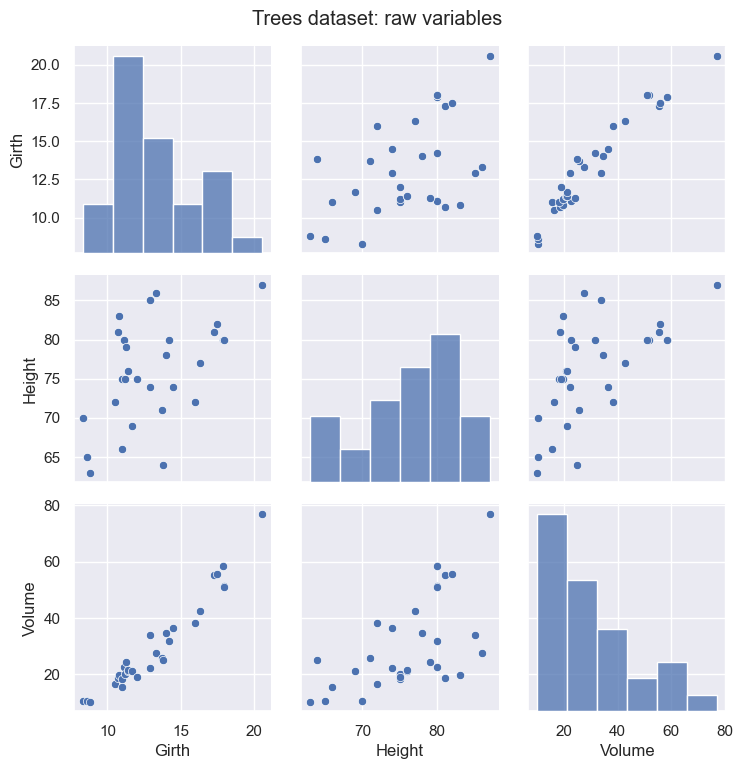

In [95]:
# Pair plot of raw variables
g = sns.PairGrid(trees)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.fig.suptitle("Trees dataset: raw variables", y=1.02)
plt.show()

The relationships between Volume and both Girth and Height appear **non-linear** (curved scatter). This is expected from the geometric relationship $V \propto d^2 h$.

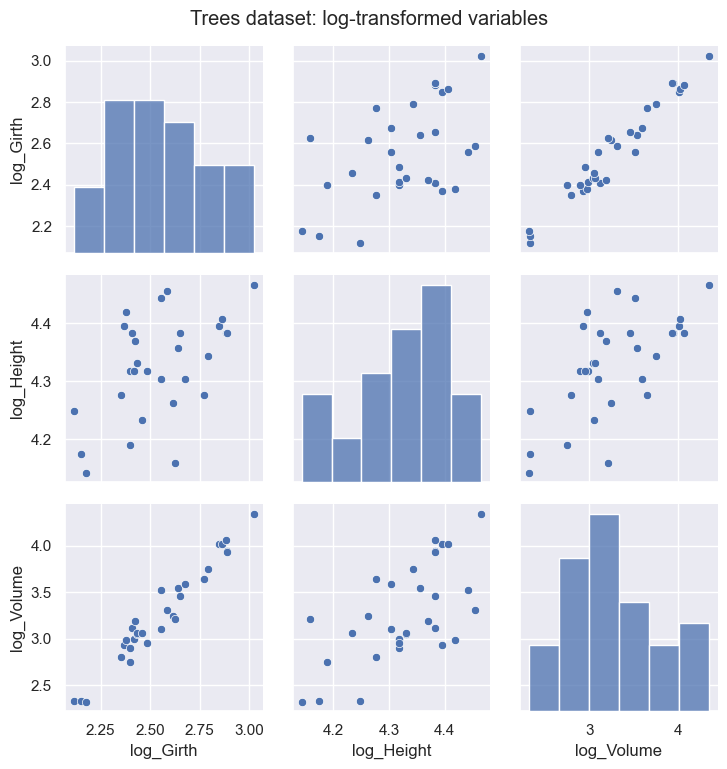

In [96]:
# Log-transformed variables
log_trees = trees.copy()
log_trees['log_Girth'] = np.log(trees['Girth'])
log_trees['log_Height'] = np.log(trees['Height'])
log_trees['log_Volume'] = np.log(trees['Volume'])

h = sns.PairGrid(log_trees[['log_Girth', 'log_Height', 'log_Volume']])
h.map_diag(sns.histplot)
h.map_offdiag(sns.scatterplot)
h.fig.suptitle("Trees dataset: log-transformed variables", y=1.02)
plt.show()

On the log scale, the relationships become approximately linear, supporting the geometric model.

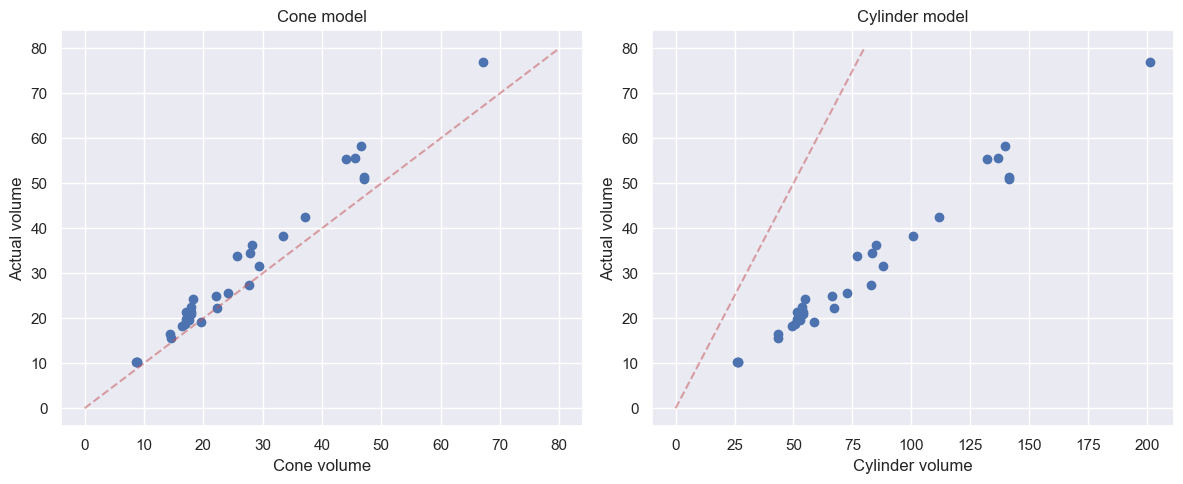

In [97]:
# Physical model: compare with cone and cylinder volumes
trans_trees = trees.copy()
trans_trees['cone'] = (np.pi * (trees['Girth'] / 12)**2 * trees['Height']) / 12
trans_trees['cylinder'] = (np.pi * (trees['Girth'] / 12)**2 * trees['Height']) / 4

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(trans_trees['cone'], trees['Volume'])
axes[0].plot([0, 80], [0, 80], 'r--', alpha=0.5)
axes[0].set_xlabel('Cone volume'); axes[0].set_ylabel('Actual volume'); axes[0].set_title('Cone model')
axes[1].scatter(trans_trees['cylinder'], trees['Volume'])
axes[1].plot([0, 80], [0, 80], 'r--', alpha=0.5)
axes[1].set_xlabel('Cylinder volume'); axes[1].set_ylabel('Actual volume'); axes[1].set_title('Cylinder model')
plt.tight_layout()
plt.show()

---
# 5. Classical Regression Approach (Recap)

Before applying GLM, let us recall how we would handle this problem using classical linear regression (from 01RAD). The log transformation linearizes the geometric relationship.

In [98]:
# Model 0: log-log OLS regression
trees_m0 = smf.ols(formula='log_Volume ~ log_Girth + log_Height', data=log_trees).fit()
print(trees_m0.summary())

                            OLS Regression Results                            
Dep. Variable:             log_Volume   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     613.2
Date:                 st, 08 dub 2026   Prob (F-statistic):           7.62e-24
Time:                        14:37:12   Log-Likelihood:                 35.356
No. Observations:                  31   AIC:                            -64.71
Df Residuals:                      28   BIC:                            -60.41
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.6316      0.800     -8.292      0.0

The log-log model gives an excellent fit ($R^2 \approx 0.98$). The coefficients are close to the geometric expectation ($\beta_{\log \text{Girth}} \approx 2$, $\beta_{\log \text{Height}} \approx 1$).

However, the classical OLS approach requires:
- Homoscedastic errors on the *transformed* scale
- The transformation must be known in advance

The GLM approach handles non-constant variance directly through the variance function and provides a principled framework for model selection.

---
# 6. GLM Approach

Since Volume is a **continuous positive** variable, we use the **Gamma family**. Recall:
- Variance function: $v(\mu) = \mu^2$ (variance proportional to the square of the mean)
- Canonical link: $g(\mu) = 1/\mu$ (inverse link)
- Common alternative: $g(\mu) = \log(\mu)$ (log link)

We will fit three models with increasing refinement:

| Model | Link | Covariates | Python formula |
|:------|:-----|:-----------|:---------------|
| M1 | $1/\mu$ (canonical) | Girth, Height | `Volume ~ Girth + Height` |
| M2 | $\log \mu$ | Girth, Height | `Volume ~ Girth + Height` |
| M3 | $\log \mu$ | $\log$(Girth), $\log$(Height) | `Volume ~ log_Girth + log_Height` |

## 6.1 Model 1: Gamma with Canonical (Inverse) Link

In [99]:
trees_m1 = smf.glm('Volume ~ Girth + Height',
                  data=trees,
                  family=sm.families.Gamma()  # default: InversePower link
                  ).fit()
print(trees_m1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Volume   No. Observations:                   31
Model:                            GLM   Df Residuals:                       28
Model Family:                   Gamma   Df Model:                            2
Link Function:           InversePower   Scale:                        0.041737
Method:                          IRLS   Log-Likelihood:                -96.435
Date:                 st, 08 dub 2026   Deviance:                       1.3038
Time:                        14:37:12   Pearson chi2:                     1.17
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9956
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1119      0.017      6.721      0.0

/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


### Pseudo-$R^2$ Measures

Unlike OLS, GLMs do not have a natural $R^2$. Several pseudo-$R^2$ measures are used:

**Cox & Snell:**
$$R_{\text{CS}}^2 = 1 - \exp\!\left(\frac{2(l_0 - l_M)}{n}\right)$$

where $l_0$ is the null model log-likelihood and $l_M$ is the fitted model log-likelihood.

**McFadden:**
$$R_{\text{McF}}^2 = 1 - \frac{l_M}{l_0}$$

Note that `statsmodels` computes both measures using log-likelihoods (`llf`, `llnull`), **not** deviances. The deviance-based ratio $1 - D/D_0$ ("proportion of deviance explained") is a related but distinct quantity.

**Remark:** When comparing two different models, they can have different estimated dispersion $\hat{\phi}$, which affects pseudo-$R^2$ values. Always compare pseudo-$R^2$ values with caution.

In [100]:
# Pseudo R-squared values
R2_CS = trees_m1.pseudo_rsquared(kind='cs')
R2_McF = trees_m1.pseudo_rsquared(kind='mcf')

# Null model for comparison
null_model = smf.glm('Volume ~ 1', data=trees, family=sm.families.Gamma()).fit()

print(f"Cox & Snell pseudo R-squared: {R2_CS:.4f}")
print(f"McFadden pseudo R-squared:    {R2_McF:.4f}")
print(f"\nNull deviance:  {trees_m1.null_deviance:.4f}  (df = {int(trees_m1.nobs - 1)})")
print(f"Model deviance: {trees_m1.deviance:.4f}  (df = {int(trees_m1.df_resid)})")
print(f"Estimated dispersion (phi): {trees_m1.scale:.6f}")

Cox & Snell pseudo R-squared: 0.9956
McFadden pseudo R-squared:    0.4656

Null deviance:  8.3172  (df = 30)
Model deviance: 1.3038  (df = 28)
Estimated dispersion (phi): 0.041737


/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


### Pearson Chi-Squared Statistic and Deviance

The **Pearson chi-squared statistic** is:
$$X^2 = \sum_{i=1}^n (r_i^P)^2 = \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{v(\hat{\mu}_i)}$$

For the Gamma family, $v(\mu) = \mu^2$, so:
$$X^2 = \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{\hat{\mu}_i^2}$$

The **deviance** for the Gamma family is:
$$D = 2 \sum_{i=1}^n \left[ \frac{y_i - \hat{\mu}_i}{\hat{\mu}_i} - \log\frac{y_i}{\hat{\mu}_i} \right]$$

Both provide estimates of the dispersion parameter: $\hat{\phi}_P = X^2/(n-p)$, $\hat{\phi}_D = D/(n-p)$.

In [101]:
# Manual computation of Pearson chi-squared and deviance for Gamma
y = trees_m1.model.endog
mu_hat = trees_m1.fittedvalues
v_mu = mu_hat**2  # Gamma variance function

# Pearson chi-squared
pearson_chi2 = np.sum((y - mu_hat)**2 / v_mu)

# Deviance (Gamma)
deviance_manual = 2 * np.sum((y - mu_hat) / mu_hat - np.log(y / mu_hat))

print(f"Pearson chi-squared (manual):  {pearson_chi2:.4f}")
print(f"Pearson chi-squared (model):   {trees_m1.pearson_chi2:.4f}")
print(f"\nDeviance (manual):  {deviance_manual:.4f}")
print(f"Deviance (model):   {trees_m1.deviance:.4f}")
print(f"\nDispersion (Pearson): {pearson_chi2 / trees_m1.df_resid:.6f}")
print(f"Dispersion (model):   {trees_m1.scale:.6f}")

Pearson chi-squared (manual):  1.1686
Pearson chi-squared (model):   1.1686

Deviance (manual):  1.3038
Deviance (model):   1.3038

Dispersion (Pearson): 0.041737
Dispersion (model):   0.041737


## 6.2 Residual Analysis for Model 1

Let us compute all types of residuals manually and compare with `statsmodels` output. The Gamma model is necessarily **heteroscedastic** because $\mathrm{Var}(Y_i) = \phi\, \mu_i^2$.

In [102]:
# Extract model components
y = trees_m1.model.endog
mu_hat = trees_m1.fittedvalues
v_mu = mu_hat**2  # Gamma variance function: v(mu) = mu^2
phi_hat = trees_m1.scale
influence = trees_m1.get_influence()
h = influence.hat_matrix_diag  # leverage values

# Response residuals
r_response = y - mu_hat

# Working residuals (from statsmodels)
r_working_sm = trees_m1.resid_working

# Pearson residuals
r_pearson = (y - mu_hat) / np.sqrt(v_mu)

# Standardized Pearson residuals
r_pearson_std = r_pearson / np.sqrt(phi_hat * (1 - h))

# Deviance residuals
r_deviance = trees_m1.resid_deviance

# Standardized deviance residuals
r_deviance_std = r_deviance / np.sqrt(phi_hat * (1 - h))

# Anscombe residuals (scaled)
r_anscombe = trees_m1.resid_anscombe_scaled

# Compile into a DataFrame
residuals_df = pd.DataFrame({
    'y': y,
    'mu_hat': mu_hat,
    'r_response': r_response,
    'r_working': r_working_sm,
    'r_pearson': r_pearson,
    'r_pearson_std': r_pearson_std,
    'r_deviance': r_deviance,
    'r_deviance_std': r_deviance_std,
    'r_anscombe': r_anscombe,
    'h_ii': h
})
residuals_df.round(4).head(10)

,y,mu_hat,r_response,r_working,r_pearson,r_pearson_std,r_deviance,r_deviance_std,r_anscombe,h_ii
0,10.3,16.4417,-6.1417,0.0227,-0.3735,-1.8753,-0.4339,-2.1782,-2.1197,0.0493
1,10.3,16.3970,-6.0970,0.0227,-0.3718,-1.8750,-0.4316,-2.1761,-2.1083,0.0577
2,10.2,16.4633,-6.2633,0.0231,-0.3804,-1.9304,-0.4434,-2.2499,-2.1660,0.0694
3,16.4,19.3395,-2.9395,0.0079,-0.1520,-0.7603,-0.1605,-0.8027,-0.7852,0.0425
4,18.8,20.6087,-1.8087,0.0043,-0.0878,-0.4520,-0.0905,-0.4660,-0.4428,0.0968
5,19.7,21.0089,-1.3089,0.0030,-0.0623,-0.3262,-0.0636,-0.3332,-0.3115,0.1261
6,15.6,19.4701,-3.8701,0.0102,-0.1988,-1.0098,-0.2137,-1.0858,-1.0457,0.0717
7,18.2,20.4264,-2.2264,0.0053,-0.1090,-0.5458,-0.1132,-0.5670,-0.5542,0.0445
8,22.6,21.1727,1.4273,-0.0032,0.0674,0.3439,0.0660,0.3365,0.3228,0.0797
9,19.9,20.7571,-0.8571,0.0020,-0.0413,-0.2066,-0.0419,-0.2095,-0.2050,0.0432


**Verification:** Let us check that our manual Pearson residuals match `statsmodels`:

In [103]:
# Compare manual vs statsmodels Pearson residuals
print("Max abs difference (Pearson): ",
      np.max(np.abs(r_pearson - trees_m1.resid_pearson)))
print("Max abs difference (Deviance): ",
      np.max(np.abs(r_deviance - trees_m1.resid_deviance)))

Max abs difference (Pearson):  0.0
Max abs difference (Deviance):  0.0


## 6.3 Diagnostic Plots for Model 1

We produce the standard diagnostic plots. For GLMs, we use **standardized deviance residuals** as the primary residual type.

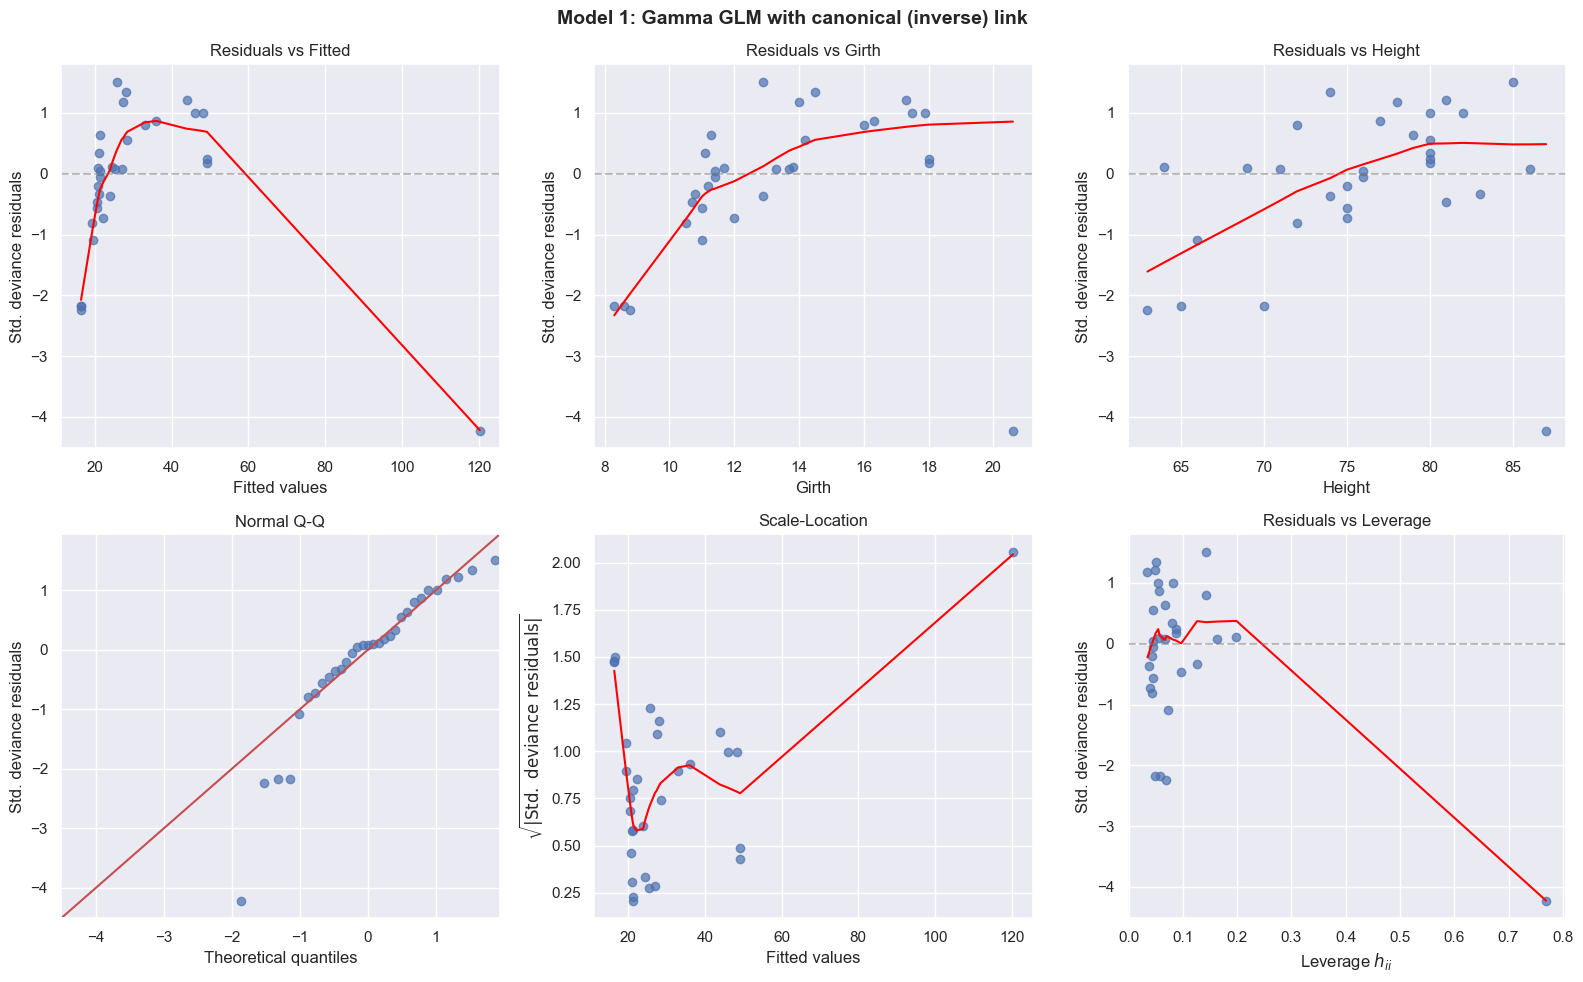

In [104]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(mu_hat, r_deviance_std, alpha=0.7)
sns.regplot(x=mu_hat, y=r_deviance_std, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 0])
axes[0, 0].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Residuals vs Girth
axes[0, 1].scatter(trees['Girth'], r_deviance_std, alpha=0.7)
sns.regplot(x=trees['Girth'].values, y=r_deviance_std, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 1])
axes[0, 1].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 1].set_xlabel('Girth')
axes[0, 1].set_ylabel('Std. deviance residuals')
axes[0, 1].set_title('Residuals vs Girth')

# 3. Residuals vs Height
axes[0, 2].scatter(trees['Height'], r_deviance_std, alpha=0.7)
sns.regplot(x=trees['Height'].values, y=r_deviance_std, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 2])
axes[0, 2].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 2].set_xlabel('Height')
axes[0, 2].set_ylabel('Std. deviance residuals')
axes[0, 2].set_title('Residuals vs Height')

# 4. Q-Q Plot
QQ = ProbPlot(r_deviance_std)
QQ.qqplot(line='45', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q')
axes[1, 0].set_xlabel('Theoretical quantiles')
axes[1, 0].set_ylabel('Std. deviance residuals')

# 5. Scale-Location
sqrt_abs_resid = np.sqrt(np.abs(r_deviance_std))
axes[1, 1].scatter(mu_hat, sqrt_abs_resid, alpha=0.7)
sns.regplot(x=mu_hat, y=sqrt_abs_resid, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[1, 1])
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel(r'$\sqrt{|\mathrm{Std.\ deviance\ residuals}|}$')
axes[1, 1].set_title('Scale-Location')

# 6. Residuals vs Leverage
axes[1, 2].scatter(h, r_deviance_std, alpha=0.7)
sns.regplot(x=h, y=r_deviance_std, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[1, 2])
axes[1, 2].axhline(0, color='grey', ls='--', alpha=0.5)
axes[1, 2].set_xlabel(r'Leverage $h_{ii}$')
axes[1, 2].set_ylabel('Std. deviance residuals')
axes[1, 2].set_title('Residuals vs Leverage')

plt.suptitle('Model 1: Gamma GLM with canonical (inverse) link', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Model 1 diagnostics:**
- The residuals vs fitted plot shows a clear **curved pattern** -- the model is not capturing the non-linearity.
- Residuals vs Girth also shows systematic structure.
- The Q-Q plot shows departures from normality.
- Overall: the **canonical (inverse) link function** may not be appropriate. Let us validate this more formally.

## 6.4 Link Function Validation

To validate the link function, we plot **working responses**  = \hat{\eta}_i + (y_i - \hat{\mu}_i)\, g'(\hat{\mu}_i)$ against the linear predictor $\hat{\eta}_i$.

If the link function is correct, this relationship should be approximately linear with slope 1.

### Theoretical Justification

**Step 1: Working response as a Taylor expansion.**
The working response  is a first-order Taylor expansion of $(y_i)$ around $\hat{\mu}_i$:

$$g(y_i) \approx g(\hat{\mu}_i) + g'(\hat{\mu}_i)\,(y_i - \hat{\mu}_i) = \hat{\eta}_i + g'(\hat{\mu}_i)\,(y_i - \hat{\mu}_i) = z_i$$

So  is a linearized version of $(y_i)$.

**Step 2: Expected value of $.**

If the model is correct, $[Y_i] = \mu_i$ and $\hat{\mu}_i \xrightarrow{P} \mu_i$ (MLE consistency). Then:

$$[z_i] \approx \hat{\eta}_i + g'(\hat{\mu}_i)\, \underbrace{E[y_i - \hat{\mu}_i]}_{\approx\, 0} \approx \hat{\eta}_i$$

We can write  $= \hat{\eta}_i + \varepsilon_i^*$, where $\varepsilon_i^* = (y_i - \hat{\mu}_i)\,g'(\hat{\mu}_i)$ is a "linearized residual" with $[\varepsilon_i^*] \approx 0$. Therefore:

$$[z_i \mid \hat{\eta}_i] \approx \hat{\eta}_i$$

which is a line with **slope 1 through the origin** (the identity).

**Step 3: What happens with a wrong link function?**
Suppose the true model uses link $^*$, but we fit with link  $\neq g^*$. The true structure is $^*(\mu_i) = x_i^T \beta^*$, i.e., $\mu_i = g^{*-1}(x_i^T \beta^*)$. The working response still linearizes $(y_i)$, so:

$$[z_i] \approx g(\mu_i) = g\!\left(g^{*-1}(x_i^T \beta^*)\right)$$

The relationship between $[z_i]$ and $\hat{\eta}_i$ is mediated by the composition  $\circ g^{*-1}$:

| Situation |  \circ g^{*-1}$ | Plot of $ vs $\hat{\eta}$ |
|:----------|:------------------|:----------------------------|
| Correct link ( = g^*$) | identity | straight line, slope 1 |
| Wrong link ( \neq g^*$) | nonlinear | **curvature** |

**Example (our Model 1):** The true model is approximately $\log(\mu_i) = x_i^T \beta$ (log link), but we fit with the canonical inverse link (\mu) = 1/\mu$. Then:

$$g \circ g^{*-1}(\eta^*) = \frac{1}{e^{\eta^*}} = e^{-\eta^*}$$

which is a convex exponential curve -- this is exactly the curvature we expect to see in the plot below.

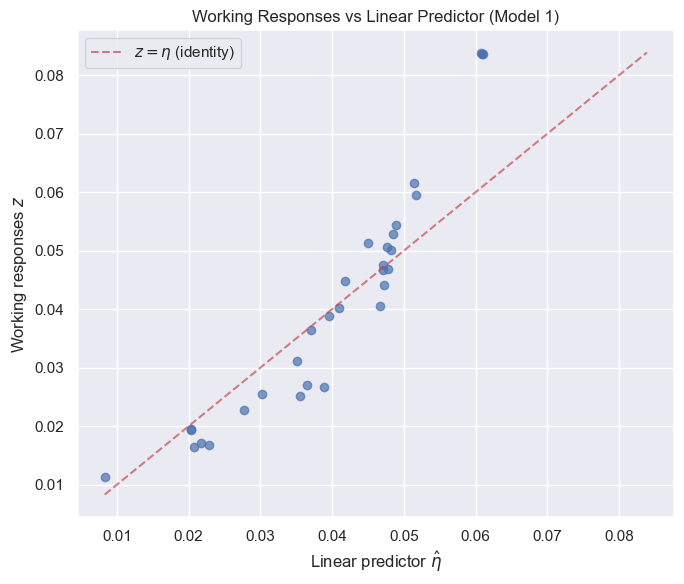

In [105]:
# Working responses: z_i = eta_hat + (y - mu_hat) * g'(mu_hat)
# For inverse link: g(mu) = 1/mu, g'(mu) = -1/mu^2
eta_hat = trees_m1.predict(which='linear')
g_prime = -1 / mu_hat**2  # derivative of inverse link
z = eta_hat + (y - mu_hat) * g_prime

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(eta_hat, z, alpha=0.7)
# Add identity line
lims = [min(eta_hat.min(), z.min()), max(eta_hat.max(), z.max())]
ax.plot(lims, lims, 'r--', alpha=0.7, label='$z = \eta$ (identity)')
ax.set_xlabel(r'Linear predictor $\hat{\eta}$')
ax.set_ylabel(r'Working responses $z$')
ax.set_title('Working Responses vs Linear Predictor (Model 1)')
ax.legend()
plt.tight_layout()
plt.show()

The working response plot shows **significant departure from the identity line**, confirming that the inverse link function is not appropriate for this data. We should try the **log link**.

## 6.5 Partial Residual Plots for Model 1

Partial residual plots help determine if covariates are included on the correct scale.

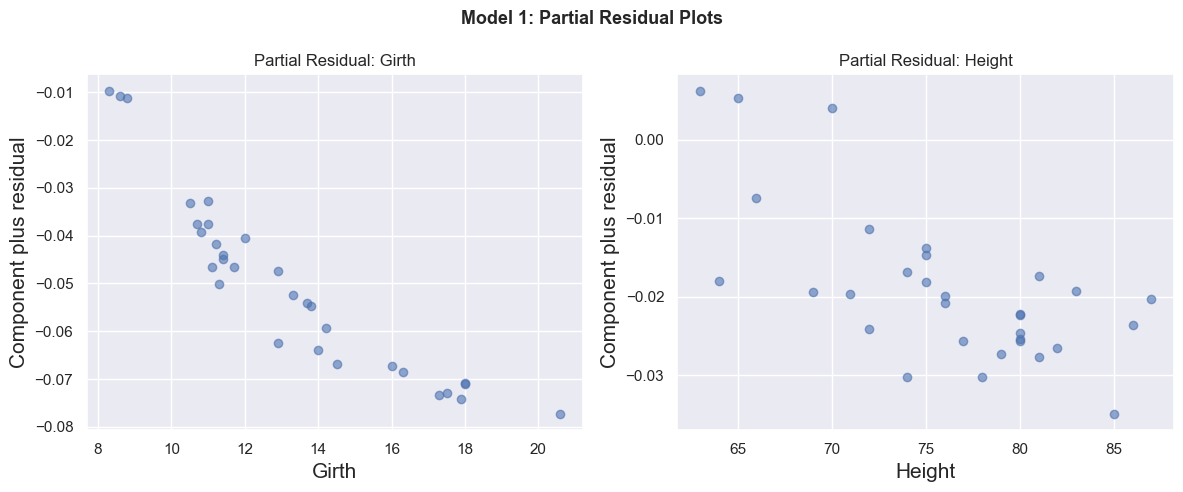

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Partial residuals for Girth
trees_m1.plot_partial_residuals('Girth', ax=axes[0])
axes[0].set_title('Partial Residual: Girth')

# Partial residuals for Height
trees_m1.plot_partial_residuals('Height', ax=axes[1])
axes[1].set_title('Partial Residual: Height')

plt.suptitle('Model 1: Partial Residual Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The partial residual plots show non-linear patterns for both Girth and Height, suggesting that the covariates may need transformation.

**Conclusion for Model 1:** The canonical (inverse) link is inappropriate. The residual and partial residual plots show systematic patterns.

---
# 7. Model 2: Gamma with Log Link

The log link $g(\mu) = \log(\mu)$ is a natural choice for positive response variables and is more interpretable than the inverse link.

In [107]:
trees_m2 = smf.glm('Volume ~ Girth + Height',
                  data=trees,
                  family=sm.families.Gamma(link=sm.families.links.Log())
                  ).fit()
print(trees_m2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Volume   No. Observations:                   31
Model:                            GLM   Df Residuals:                       28
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                       0.0094102
Method:                          IRLS   Log-Likelihood:                -71.590
Date:                 st, 08 dub 2026   Deviance:                      0.26247
Time:                        14:37:12   Pearson chi2:                    0.263
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0923      0.216      0.428      0.6

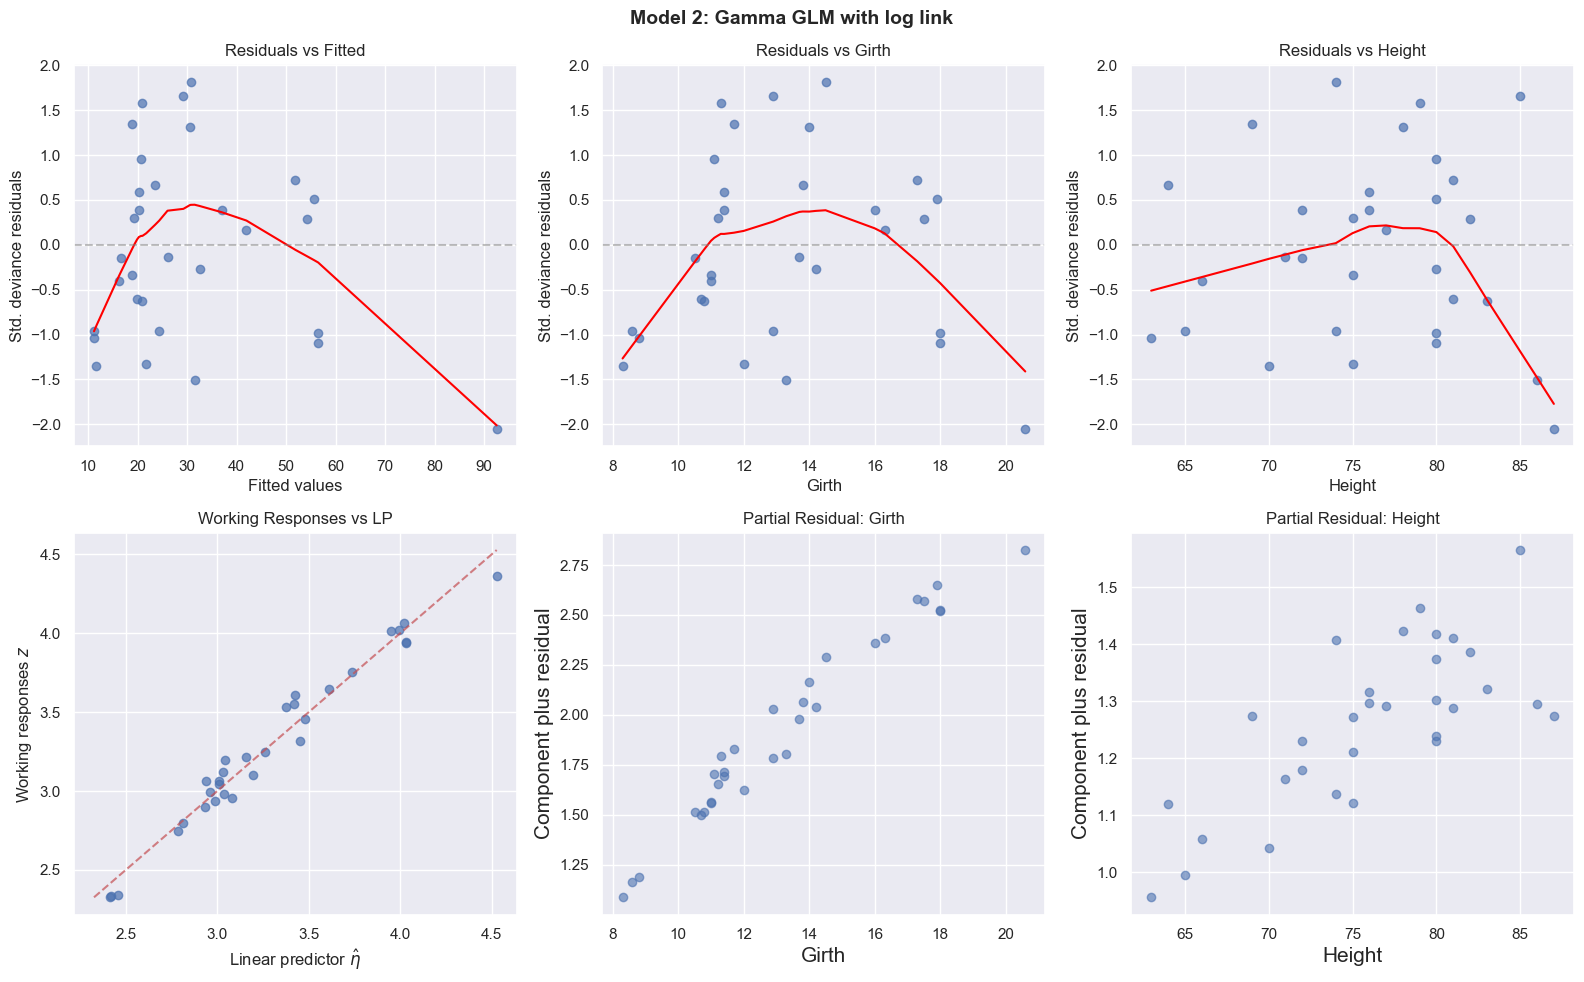

In [108]:
# Diagnostic plots for Model 2
y2 = trees_m2.model.endog
mu2 = trees_m2.fittedvalues
infl2 = trees_m2.get_influence()
h2 = infl2.hat_matrix_diag
r_dev_std2 = trees_m2.resid_deviance / np.sqrt(trees_m2.scale * (1 - h2))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Residuals vs Fitted
axes[0, 0].scatter(mu2, r_dev_std2, alpha=0.7)
sns.regplot(x=mu2, y=r_dev_std2, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 0])
axes[0, 0].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Residuals vs Girth
axes[0, 1].scatter(trees['Girth'], r_dev_std2, alpha=0.7)
sns.regplot(x=trees['Girth'].values, y=r_dev_std2, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 1])
axes[0, 1].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 1].set_xlabel('Girth'); axes[0, 1].set_ylabel('Std. deviance residuals')
axes[0, 1].set_title('Residuals vs Girth')

# Residuals vs Height
axes[0, 2].scatter(trees['Height'], r_dev_std2, alpha=0.7)
sns.regplot(x=trees['Height'].values, y=r_dev_std2, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 2])
axes[0, 2].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 2].set_xlabel('Height'); axes[0, 2].set_ylabel('Std. deviance residuals')
axes[0, 2].set_title('Residuals vs Height')

# Working responses
eta2 = trees_m2.predict(which='linear')
g_prime2 = 1 / mu2  # derivative of log link: g'(mu) = 1/mu
z2 = eta2 + (y2 - mu2) * g_prime2
axes[1, 0].scatter(eta2, z2, alpha=0.7)
lims2 = [min(eta2.min(), z2.min()), max(eta2.max(), z2.max())]
axes[1, 0].plot(lims2, lims2, 'r--', alpha=0.7)
axes[1, 0].set_xlabel(r'Linear predictor $\hat{\eta}$')
axes[1, 0].set_ylabel(r'Working responses $z$')
axes[1, 0].set_title('Working Responses vs LP')

# Partial residuals
trees_m2.plot_partial_residuals('Girth', ax=axes[1, 1])
axes[1, 1].set_title('Partial Residual: Girth')

trees_m2.plot_partial_residuals('Height', ax=axes[1, 2])
axes[1, 2].set_title('Partial Residual: Height')

plt.suptitle('Model 2: Gamma GLM with log link', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Model 2 diagnostics:**
- The working responses vs linear predictor plot is now close to the identity line -- the **log link is appropriate**.
- However, the residuals vs Girth still show a **curved pattern** -- the systematic component needs improvement.
- The partial residual plots suggest that both Girth and Height should be **log-transformed**.

---
# 8. Model 3: Gamma with Log Link and Log Covariates

Based on the diagnostic analysis of Models 1 and 2, we now fit Model 3 with:
- **Log link** (validated by the working response plot)
- **Log-transformed covariates** (suggested by partial residual plots)

This corresponds to the model: $\log(\mu_i) = \beta_0 + \beta_1 \log(\text{Girth}_i) + \beta_2 \log(\text{Height}_i)$.

In [109]:
trees_m3 = smf.glm('Volume ~ log_Girth + log_Height',
                  data=log_trees,
                  family=sm.families.Gamma(link=sm.families.links.Log())
                  ).fit()
print(trees_m3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Volume   No. Observations:                   31
Model:                            GLM   Df Residuals:                       28
Model Family:                   Gamma   Df Model:                            2
Link Function:                    Log   Scale:                       0.0064273
Method:                          IRLS   Log-Likelihood:                -66.003
Date:                 st, 08 dub 2026   Deviance:                      0.18352
Time:                        14:37:13   Pearson chi2:                    0.180
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.6911      0.788     -8.493      0.0

All covariates are highly significant. Note that $\hat{\beta}_1 \approx 2$ and $\hat{\beta}_2 \approx 1$, consistent with the geometric expectation $V \propto d^2 h$.

## 8.1 Diagnostics for Model 3

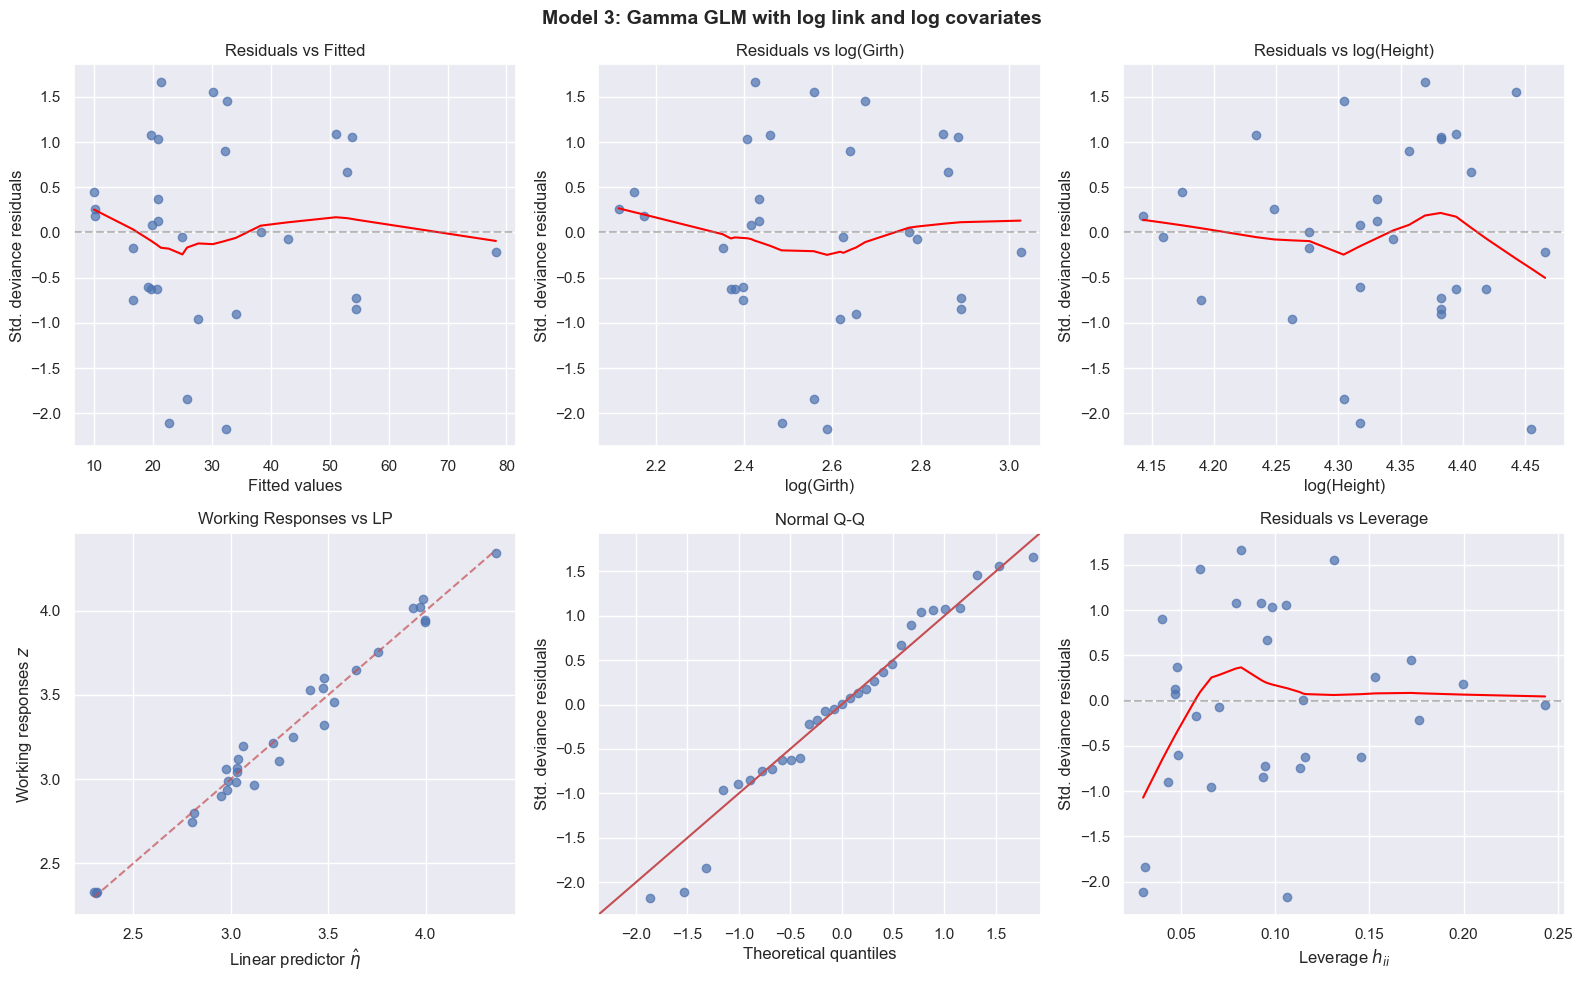

In [110]:
# Comprehensive diagnostic plots for Model 3
y3 = trees_m3.model.endog
mu3 = trees_m3.fittedvalues
infl3 = trees_m3.get_influence()
h3 = infl3.hat_matrix_diag
r_dev_std3 = trees_m3.resid_deviance / np.sqrt(trees_m3.scale * (1 - h3))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Residuals vs Fitted
axes[0, 0].scatter(mu3, r_dev_std3, alpha=0.7)
sns.regplot(x=mu3, y=r_dev_std3, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 0])
axes[0, 0].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Residuals vs log(Girth)
axes[0, 1].scatter(log_trees['log_Girth'], r_dev_std3, alpha=0.7)
sns.regplot(x=log_trees['log_Girth'].values, y=r_dev_std3, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 1])
axes[0, 1].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 1].set_xlabel('log(Girth)'); axes[0, 1].set_ylabel('Std. deviance residuals')
axes[0, 1].set_title('Residuals vs log(Girth)')

# Residuals vs log(Height)
axes[0, 2].scatter(log_trees['log_Height'], r_dev_std3, alpha=0.7)
sns.regplot(x=log_trees['log_Height'].values, y=r_dev_std3, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0, 2])
axes[0, 2].axhline(0, color='grey', ls='--', alpha=0.5)
axes[0, 2].set_xlabel('log(Height)'); axes[0, 2].set_ylabel('Std. deviance residuals')
axes[0, 2].set_title('Residuals vs log(Height)')

# Working responses
eta3 = trees_m3.predict(which='linear')
g_prime3 = 1 / mu3
z3 = eta3 + (y3 - mu3) * g_prime3
axes[1, 0].scatter(eta3, z3, alpha=0.7)
lims3 = [min(eta3.min(), z3.min()), max(eta3.max(), z3.max())]
axes[1, 0].plot(lims3, lims3, 'r--', alpha=0.7)
axes[1, 0].set_xlabel(r'Linear predictor $\hat{\eta}$')
axes[1, 0].set_ylabel(r'Working responses $z$')
axes[1, 0].set_title('Working Responses vs LP')

# Q-Q Plot
QQ3 = ProbPlot(r_dev_std3)
QQ3.qqplot(line='45', alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Normal Q-Q')
axes[1, 1].set_xlabel('Theoretical quantiles')
axes[1, 1].set_ylabel('Std. deviance residuals')

# Residuals vs Leverage
cooks3 = infl3.cooks_distance[0]
axes[1, 2].scatter(h3, r_dev_std3, alpha=0.7)
sns.regplot(x=h3, y=r_dev_std3, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 1.5}, ax=axes[1, 2])
axes[1, 2].axhline(0, color='grey', ls='--', alpha=0.5)
axes[1, 2].set_xlabel(r'Leverage $h_{ii}$'); axes[1, 2].set_ylabel('Std. deviance residuals')
axes[1, 2].set_title('Residuals vs Leverage')

plt.suptitle('Model 3: Gamma GLM with log link and log covariates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Model 3 diagnostics:**
- Residuals vs fitted values: **no systematic pattern** -- good!
- Residuals vs covariates: approximately random scatter
- Working responses vs linear predictor: close to identity -- **link function is correct**
- Q-Q plot: points lie close to the diagonal -- residuals are approximately normal
- **Model 3 appears adequate!**

## 8.2 Normality of Residuals

**Important caveat:** Normality of residuals is **not** a GLM assumption. GLMs assume that the response belongs to an exponential family, not that the errors are Gaussian. Checking approximate normality of standardized residuals is a useful *diagnostic heuristic* — if residuals are far from normal, the variance function or link may be misspecified — but a formal normality test is not required for the model to be valid.

### Question: Are the residuals from Model 3 approximately normal?

We use Anscombe residuals (designed for approximate normality) and the Shapiro-Wilk test as a rough check.

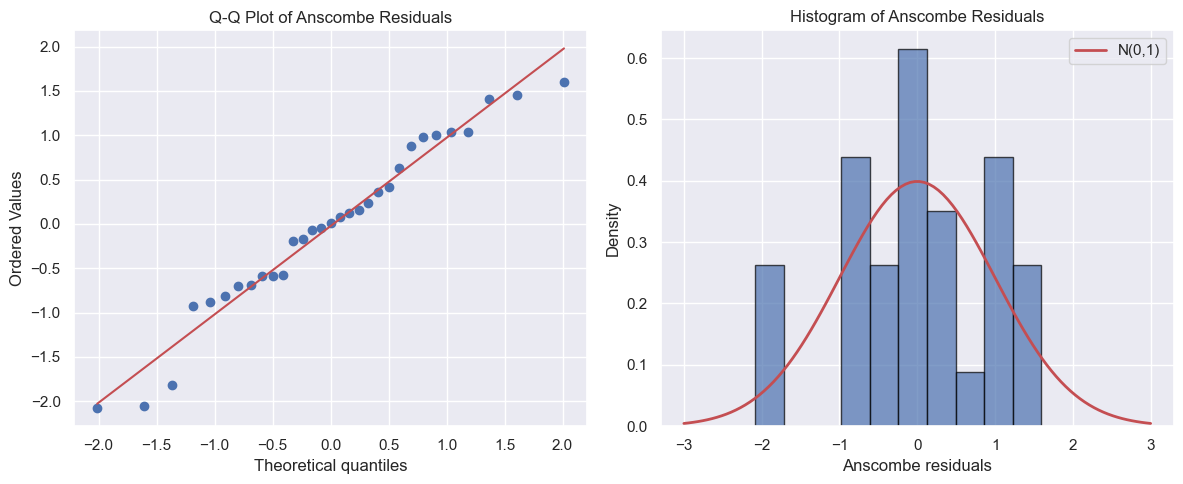

In [111]:
# Anscombe residuals for Model 3
r_anscombe3 = trees_m3.resid_anscombe_scaled

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot of Anscombe residuals
stats.probplot(r_anscombe3, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Anscombe Residuals')

# Histogram
axes[1].hist(r_anscombe3, bins=10, density=True, alpha=0.7, edgecolor='black')
x_norm = np.linspace(-3, 3, 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm), 'r-', lw=2, label='N(0,1)')
axes[1].set_xlabel('Anscombe residuals')
axes[1].set_ylabel('Density')
axes[1].set_title('Histogram of Anscombe Residuals')
axes[1].legend()

plt.tight_layout()
plt.show()

In [112]:
# Shapiro-Wilk normality test (as a rough diagnostic, not a model assumption check)
sw_stat_a, sw_pval_a = stats.shapiro(r_anscombe3)
sw_stat_d, sw_pval_d = stats.shapiro(r_dev_std3)

print("Shapiro-Wilk test (Anscombe residuals):")
print(f"  statistic = {sw_stat_a:.4f}, p-value = {sw_pval_a:.4f}")
print(f"\nShapiro-Wilk test (std. deviance residuals):")
print(f"  statistic = {sw_stat_d:.4f}, p-value = {sw_pval_d:.4f}")

Shapiro-Wilk test (Anscombe residuals):
  statistic = 0.9608, p-value = 0.3068

Shapiro-Wilk test (std. deviance residuals):
  statistic = 0.9635, p-value = 0.3590


Both tests fail to reject normality at conventional significance levels. This is consistent with the model being adequate, though recall that normality is not a formal GLM requirement — it simply indicates that the variance function and link are reasonable choices.

---
# 9. Influence Analysis

We now examine whether any observations have undue influence on the Model 3 fit.

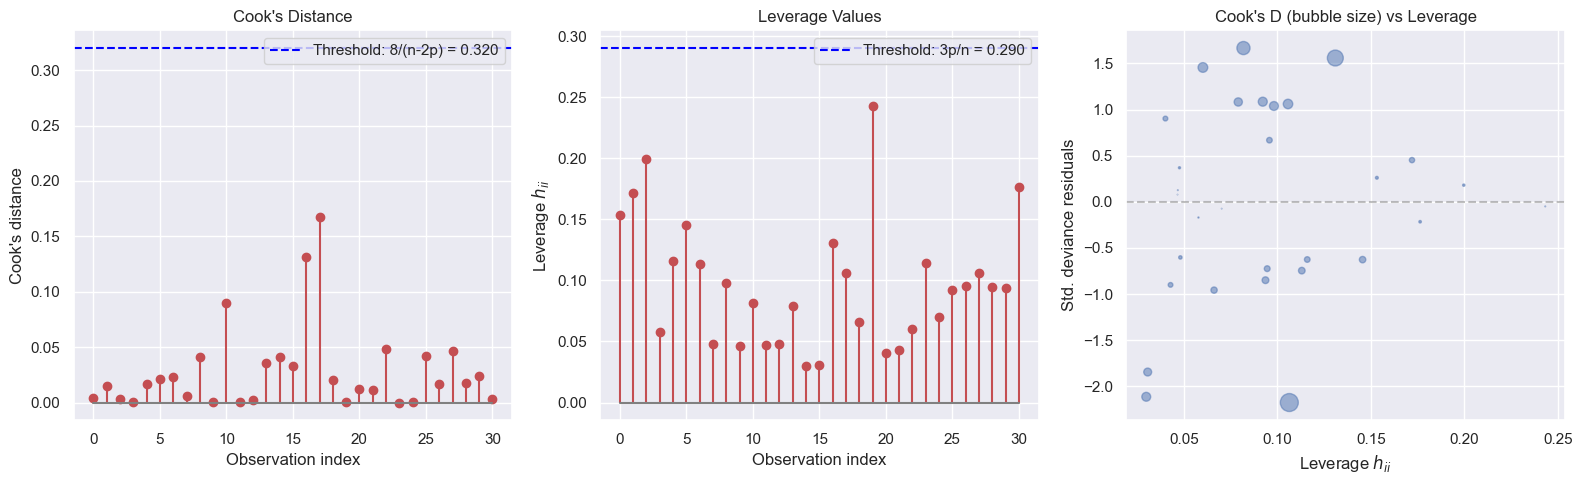

In [113]:
# Cook's distance and leverage for Model 3
n = len(y3)
p = len(trees_m3.params)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cook's distance
cooks3 = infl3.cooks_distance[0]
axes[0].stem(range(n), cooks3, markerfmt='ro', linefmt='r-', basefmt='grey')
axes[0].axhline(8 / (n - 2*p), color='blue', ls='--', label=f'Threshold: 8/(n-2p) = {8/(n-2*p):.3f}')
axes[0].set_xlabel('Observation index')
axes[0].set_ylabel("Cook's distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

# Leverage
axes[1].stem(range(n), h3, markerfmt='ro', linefmt='r-', basefmt='grey')
axes[1].axhline(3*p/n, color='blue', ls='--', label=f'Threshold: 3p/n = {3*p/n:.3f}')
axes[1].set_xlabel('Observation index')
axes[1].set_ylabel(r'Leverage $h_{ii}$')
axes[1].set_title('Leverage Values')
axes[1].legend()

# Cook's distance vs Leverage (bubble plot)
axes[2].scatter(h3, r_dev_std3, s=1000*cooks3, alpha=0.5)
axes[2].set_xlabel(r'Leverage $h_{ii}$')
axes[2].set_ylabel('Std. deviance residuals')
axes[2].set_title("Cook's D (bubble size) vs Leverage")
axes[2].axhline(0, color='grey', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [114]:
# Identify the most influential observation
max_cook_idx = np.argmax(cooks3)
print(f"Most influential observation: index {max_cook_idx}")
print(f"Cook's distance: {cooks3[max_cook_idx]:.4f}")
print(f"Threshold: {8/(n-2*p):.4f}")
print(f"\nObservation data:")
print(trees.iloc[max_cook_idx])

Most influential observation: index 17
Cook's distance: 0.1679
Threshold: 0.3200

Observation data:
Girth     13.3
Height    86.0
Volume    27.4
Name: 17, dtype: float64


### Effect of Removing the Most Influential Observation

Let us check how much the coefficients change when we remove the most influential observation:

In [115]:
# Re-fit without the most influential observation
mask = np.ones(n, dtype=bool)
mask[max_cook_idx] = False

trees_m3_drop = smf.glm('Volume ~ log_Girth + log_Height',
                        data=log_trees[mask],
                        family=sm.families.Gamma(link=sm.families.links.Log())
                        ).fit()

# Compare coefficients
coef_comparison = pd.DataFrame({
    'Full model': trees_m3.params,
    'Without obs ' + str(max_cook_idx): trees_m3_drop.params,
    'Change (%)': 100 * (trees_m3_drop.params - trees_m3.params) / trees_m3.params
}).round(4)
print(coef_comparison)

            Full model  Without obs 17  Change (%)
Intercept      -6.6911         -7.2092      7.7422
log_Girth       1.9804          1.9574     -1.1637
log_Height      1.1329          1.2675     11.8857


In [116]:
# Full influence summary
inf_summary = infl3.summary_frame()
print("Influence summary (first 10 observations):")
inf_summary.head(10).round(4)

Influence summary (first 10 observations):


,dfb_Intercept,dfb_log_Girth,dfb_log_Height,cooks_d,standard_resid,hat_diag,dffits_internal
0,0.0158,-0.0861,0.0052,0.0042,0.2623,0.1532,0.1112
1,0.1276,-0.0854,-0.0953,0.0145,0.4571,0.1720,0.2079
2,0.0683,-0.0213,-0.0565,0.0027,0.1814,0.1997,0.0905
3,-0.0107,0.0210,0.0046,0.0006,-0.1691,0.0578,-0.0418
4,0.1429,0.1673,-0.1673,0.0165,-0.6150,0.1160,-0.2230
5,0.1831,0.1864,-0.2079,0.0216,-0.6165,0.1456,-0.2549
6,-0.2204,-0.0288,0.2033,0.0227,-0.7314,0.1131,-0.2615
7,0.0144,0.0791,-0.0319,0.0059,-0.5928,0.0482,-0.1332
8,-0.2112,-0.2468,0.2480,0.0412,1.0657,0.0982,0.3520
9,-0.0015,-0.0094,0.0036,0.0001,0.0786,0.0467,0.0174


**Conclusion:** No observations have Cook's distance exceeding the threshold. The model fit is not driven by any single observation.

---
# 10. Model Comparison

Compare all three models using AIC and deviance:

In [117]:
comparison = pd.DataFrame({
    'Model': ['M1: Gamma, inverse link', 'M2: Gamma, log link', 'M3: Gamma, log link + log covariates'],
    'AIC': [trees_m1.aic, trees_m2.aic, trees_m3.aic],
    'Deviance': [trees_m1.deviance, trees_m2.deviance, trees_m3.deviance],
    'Dispersion': [trees_m1.scale, trees_m2.scale, trees_m3.scale],
    'df_resid': [int(trees_m1.df_resid), int(trees_m2.df_resid), int(trees_m3.df_resid)]
}).round(4)

print(comparison.to_string(index=False))
print(f"\nBest model by AIC: {comparison.loc[comparison['AIC'].idxmin(), 'Model']}")

                               Model      AIC  Deviance  Dispersion  df_resid
             M1: Gamma, inverse link 198.8698    1.3038      0.0417        28
                 M2: Gamma, log link 149.1800    0.2625      0.0094        28
M3: Gamma, log link + log covariates 138.0060    0.1835      0.0064        28

Best model by AIC: M3: Gamma, log link + log covariates


Model 3 has the lowest AIC, smallest deviance, and smallest estimated dispersion. Combined with the satisfactory diagnostic plots, **Model 3 is clearly the best among the three candidates**.

---
# 11. Predictions from the Final Model

Let us visualize the predictions from Model 3 overlaid on the data.

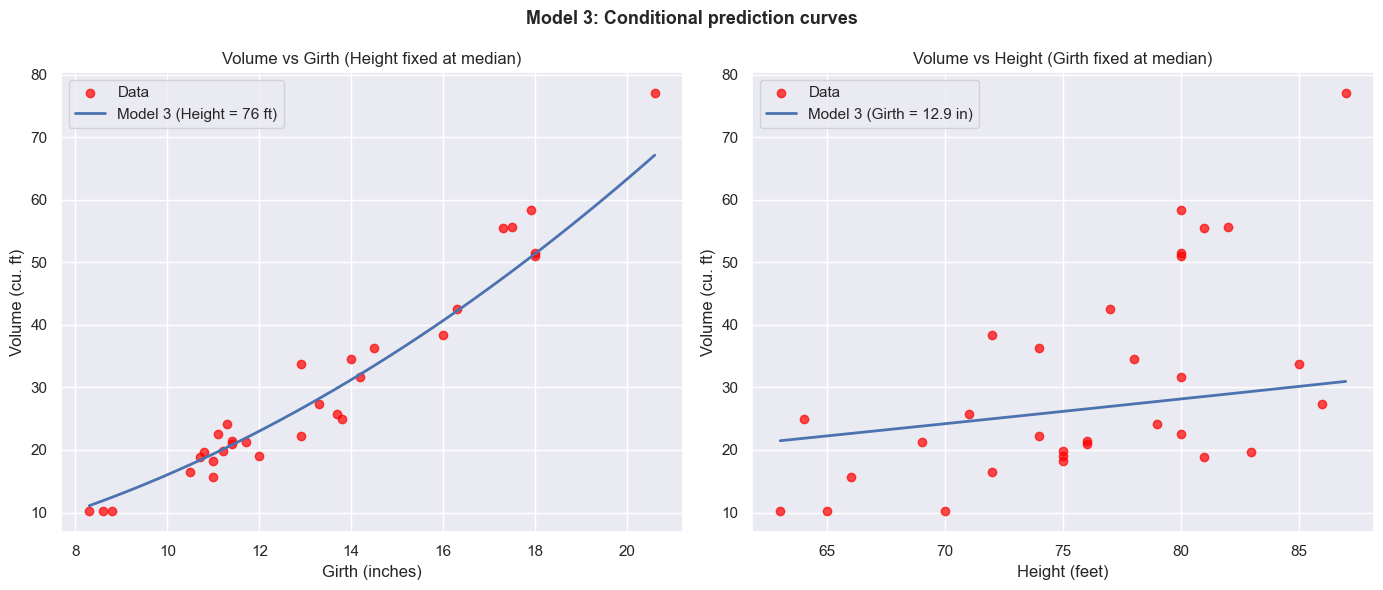

In [118]:
# Conditional prediction curves (fixing one covariate at its median)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Volume vs Girth at median Height ---
median_height = np.median(log_trees['log_Height'])
girth_grid = np.linspace(log_trees['log_Girth'].min(), log_trees['log_Girth'].max(), 100)
pred_data_g = pd.DataFrame({'log_Girth': girth_grid, 'log_Height': median_height})
pred_g = trees_m3.get_prediction(pred_data_g)
pred_mean_g = pred_g.predicted_mean

axes[0].scatter(trees['Girth'], trees['Volume'], color='red', alpha=0.7, label='Data')
axes[0].plot(np.exp(girth_grid), pred_mean_g, 'b-', lw=2,
             label=f'Model 3 (Height = {np.exp(median_height):.0f} ft)')
axes[0].set_xlabel('Girth (inches)')
axes[0].set_ylabel('Volume (cu. ft)')
axes[0].set_title('Volume vs Girth (Height fixed at median)')
axes[0].legend()

# --- Volume vs Height at median Girth ---
median_girth = np.median(log_trees['log_Girth'])
height_grid = np.linspace(log_trees['log_Height'].min(), log_trees['log_Height'].max(), 100)
pred_data_h = pd.DataFrame({'log_Girth': median_girth, 'log_Height': height_grid})
pred_h = trees_m3.get_prediction(pred_data_h)
pred_mean_h = pred_h.predicted_mean

axes[1].scatter(trees['Height'], trees['Volume'], color='red', alpha=0.7, label='Data')
axes[1].plot(np.exp(height_grid), pred_mean_h, 'b-', lw=2,
             label=f'Model 3 (Girth = {np.exp(median_girth):.1f} in)')
axes[1].set_xlabel('Height (feet)')
axes[1].set_ylabel('Volume (cu. ft)')
axes[1].set_title('Volume vs Height (Girth fixed at median)')
axes[1].legend()

plt.suptitle('Model 3: Conditional prediction curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

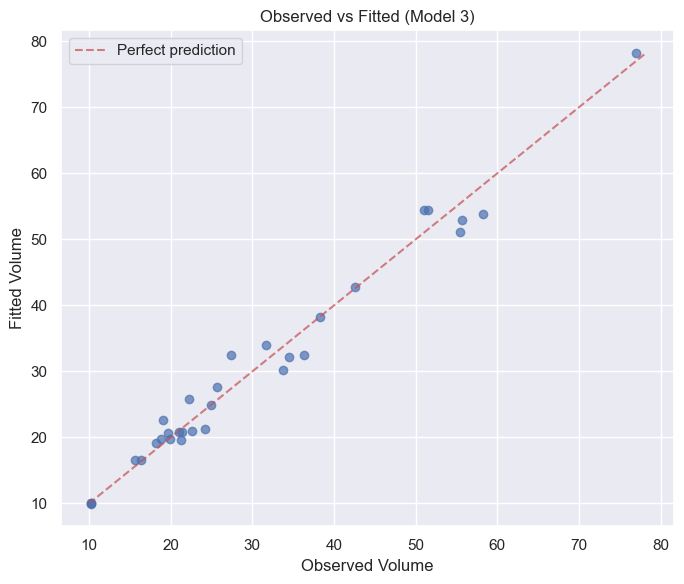

In [119]:
# Observed vs Fitted plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(trees['Volume'], mu3, alpha=0.7)
lims = [min(trees['Volume'].min(), mu3.min()), max(trees['Volume'].max(), mu3.max())]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Perfect prediction')
ax.set_xlabel('Observed Volume')
ax.set_ylabel('Fitted Volume')
ax.set_title('Observed vs Fitted (Model 3)')
ax.legend()
plt.tight_layout()
plt.show()

---
# 12. Homework: Swedish Car Accidents

## Dataset

The `sweden2.csv` dataset contains annual data on road traffic deaths in Sweden:
- **Deaths**: number of road traffic deaths
- **Petrol**: annual volume of sold fuels (in 1000 m$^3$)
- **Cars**: number of registered cars (in 1000s)
- **Vehicles**: number of registered vehicles (in 1000s)
- **Year**: calendar year

In [120]:
import io
import requests

url = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/sweden2.csv"
response = requests.get(url, verify=False)
cars = pd.read_csv(io.StringIO(response.text))
print(cars.head())
print(f"\nShape: {cars.shape}")
print(cars.describe())

   Year  Deaths  Cars  Fuel
0  1955     902   755  1531
1  1956     889   855  1657
2  1957     946   987  1738
3  1958     941  1098  1893
4  1959    1000  1216  2011

Shape: (56, 4)
              Year       Deaths         Cars         Fuel
count    56.000000    56.000000    56.000000    56.000000
mean   1982.500000   850.178571  3152.892857  4412.178571
std      16.309506   292.008101  1179.482347  1308.771875
min    1955.000000   266.000000   755.000000  1531.000000
25%    1968.750000   582.250000  2318.250000  3589.000000
50%    1982.500000   828.500000  3182.500000  4839.500000
75%    1996.250000  1093.000000  3999.000000  5508.250000
max    2010.000000  1313.000000  4884.000000  5910.000000


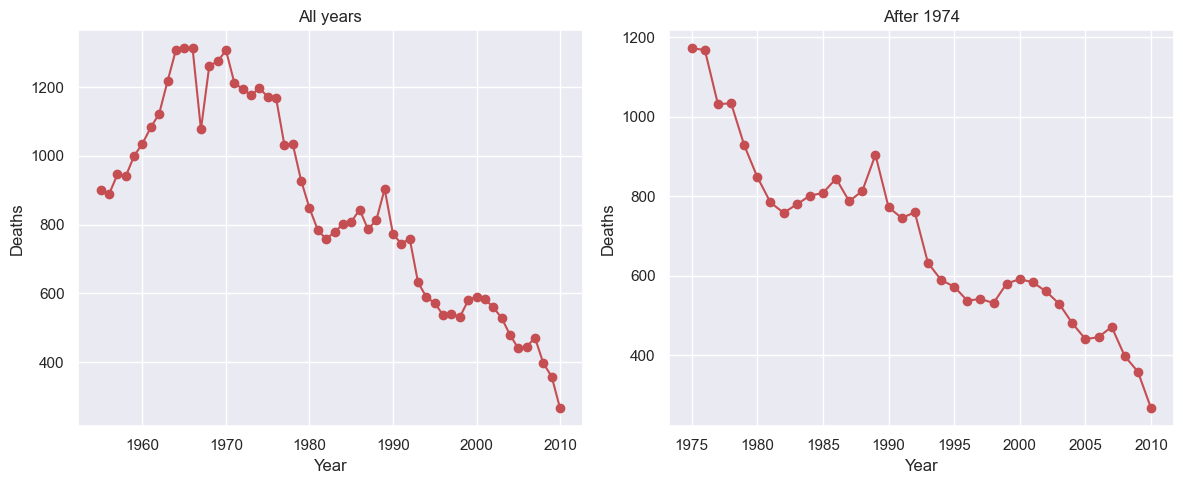

In [121]:
# Restrict to years after 1974 (structural change in traffic policy)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(cars['Year'], cars['Deaths'], 'ro-')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Deaths')
axes[0].set_title('All years')

cars = cars[cars['Year'] > 1974].reset_index(drop=True)
axes[1].plot(cars['Year'], cars['Deaths'], 'ro-')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Deaths')
axes[1].set_title('After 1974')
plt.tight_layout()
plt.show()

## Tasks

1. **Explore the data:** Produce pair plots and correlation matrices. Which variables are most strongly associated with Deaths?
2. **Fit a Poisson GLM:** Start with a model including all available predictors. Justify the choice of distribution and link function.
3. **Model selection:** Try adding interactions (up to second order) and use AIC-based selection to find the best model.
4. **Diagnostics:** For the selected model, produce:
   - Residuals vs fitted values and vs each covariate
   - Working response plot (link function validation)
   - Q-Q plot
   - Influence diagnostics (Cook's distance, leverage)
5. **Interpret the final model:** What are the significant predictors? How do you interpret the coefficients?
6. **Predictions:** Plot the predicted Deaths over the years and compare with observed values.

            Year    Deaths      Cars      Fuel
Year    1.000000 -0.944566  0.990380  0.372183
Deaths -0.944566  1.000000 -0.897560 -0.304016
Cars    0.990380 -0.897560  1.000000  0.408361
Fuel    0.372183 -0.304016  0.408361  1.000000


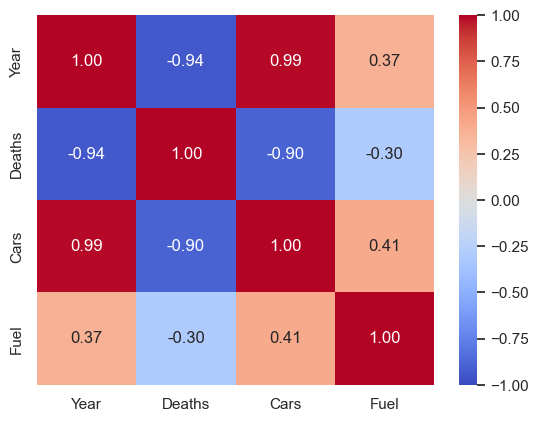

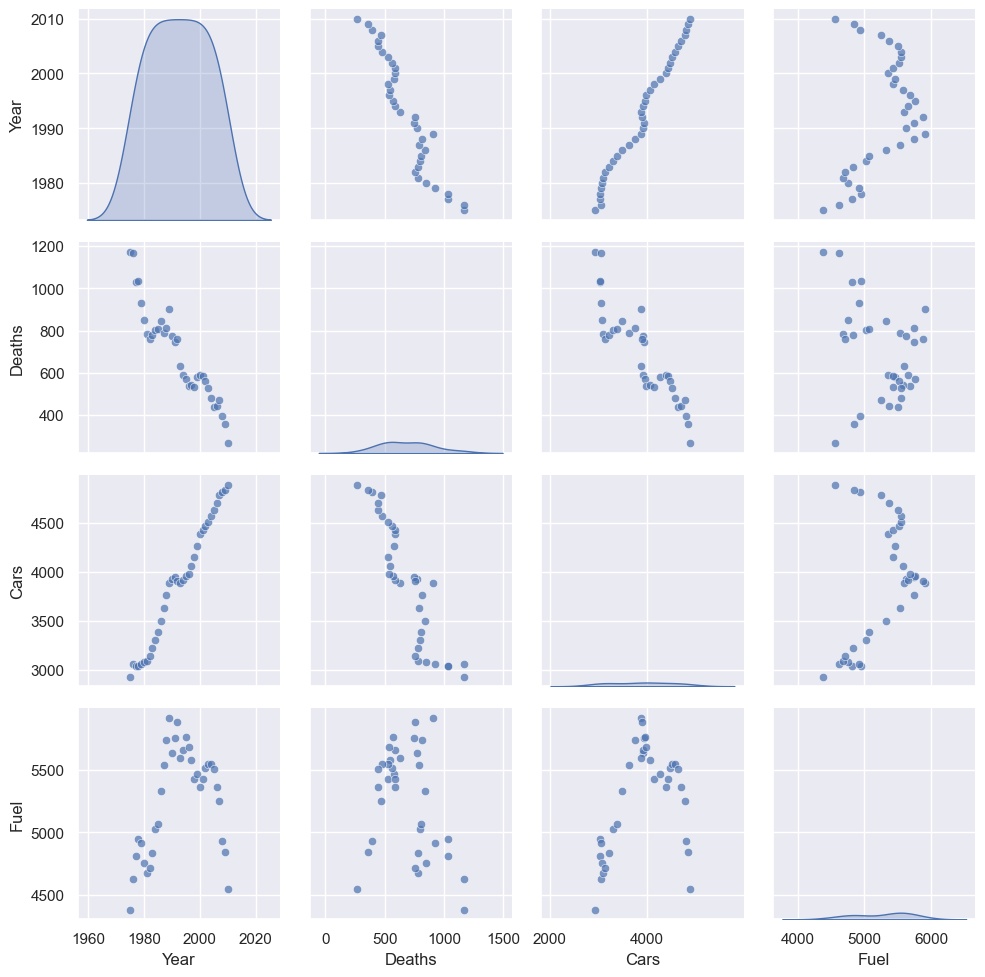

In [122]:
import pandas as pd
import seaborn as sns

correlations = cars.corr(numeric_only=True)
print(correlations)

sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

g = sns.PairGrid(cars[['Year', 'Deaths', 'Cars', 'Fuel']])
g.map_diag(sns.kdeplot, fill=True)
g.map_offdiag(sns.scatterplot, alpha=0.7)



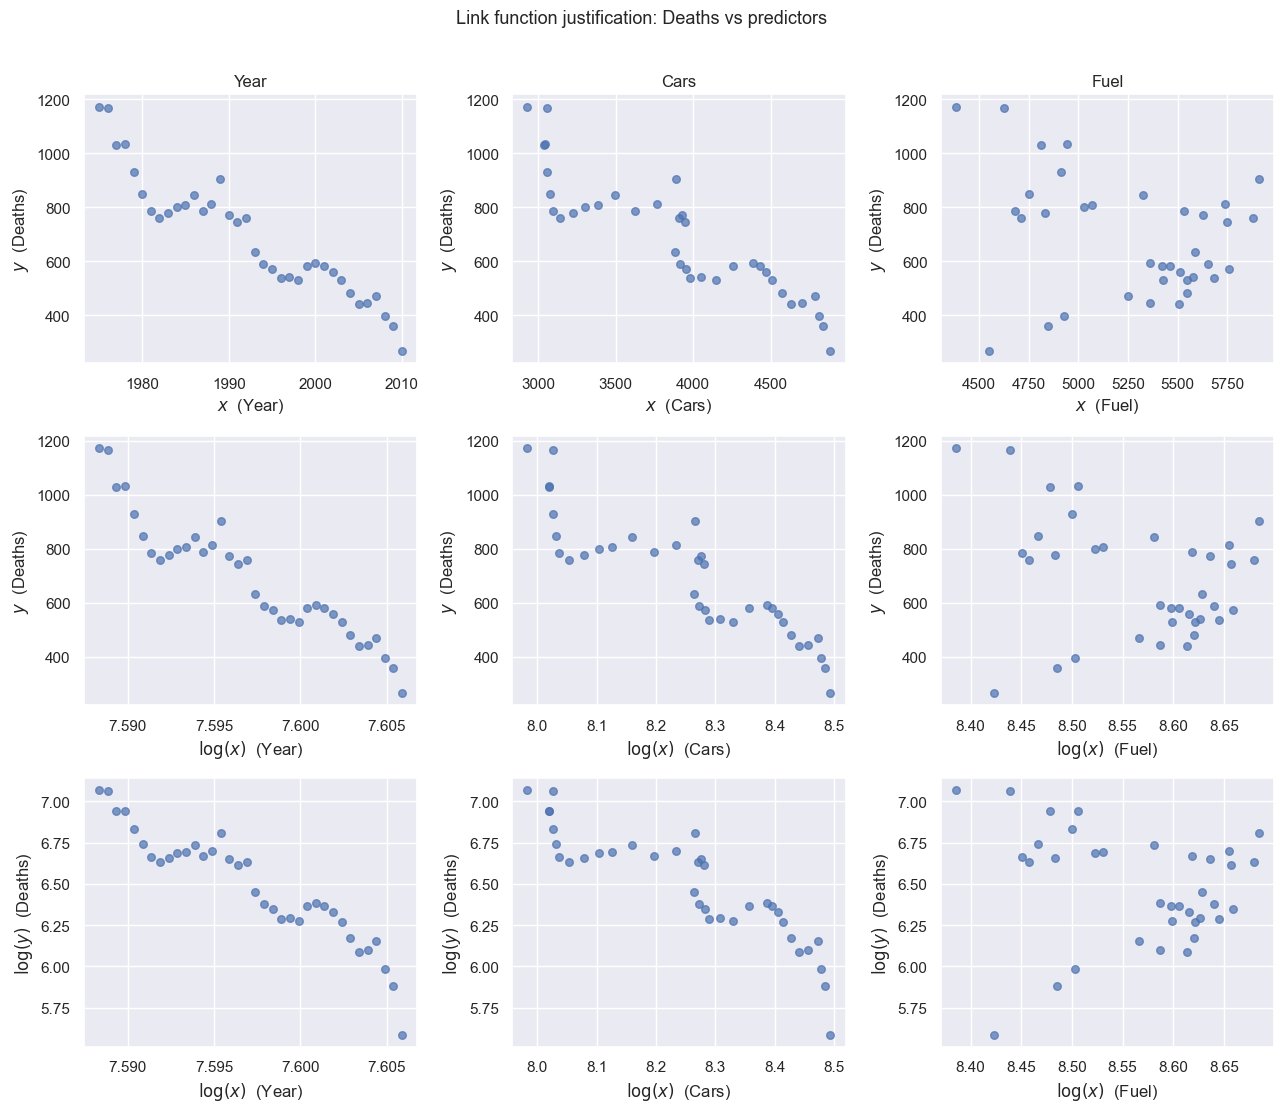

In [123]:
predictors = ['Year', 'Cars', 'Fuel']
transforms = [
    (r'$x$',            r'$y$',            lambda x: x,   lambda y: y),
    (r'$\log(x)$',   r'$y$',            np.log,        lambda y: y),
    (r'$\log(x)$',   r'$\log(y)$',   np.log,        np.log),
]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for col, pred in enumerate(predictors):
    for row, (xlabel, ylabel, fx, fy) in enumerate(transforms):
        ax = axes[row, col]
        ax.scatter(fx(cars[pred]), fy(cars['Deaths']), alpha=0.7, s=30)
        ax.set_xlabel(f'{xlabel}  ({pred})')
        ax.set_ylabel(f'{ylabel}  (Deaths)')
        if row == 0:
            ax.set_title(pred)

fig.suptitle('Link function justification: Deaths vs predictors', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [124]:
# Your code here
model1 = smf.glm(formula='Deaths ~ Year + Cars', data=cars, family=sm.families.Poisson(link=sm.families.links.Log())).fit()
print(model1.summary())

model2 = smf.glm(formula='Deaths ~ Year + Cars + Fuel', data=cars, family=sm.families.Poisson(link=sm.families.links.Log())).fit()
print(model2.summary())

model3 = smf.glm(formula='Deaths ~ Year + Cars + Fuel + Cars:Fuel', data=cars, family=sm.families.Poisson(link=sm.families.links.Log())).fit()
print(model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       33
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -199.59
Date:                 st, 08 dub 2026   Deviance:                       99.583
Time:                        14:37:14   Pearson chi2:                     95.6
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    163.2241      7.899     20.665      0.0

In [125]:
print(f"Model 1 (Year + Cars):                          BIC = {model1.bic:.2f}")
print(f"Model 2 (Year + Cars + Fuel):                   BIC = {model2.bic:.2f}")
print(f"Model 3 (Year + Cars + Fuel + Cars:Fuel):       BIC = {model3.bic:.2f}")


Model 1 (Year + Cars):                          BIC = -18.67
Model 2 (Year + Cars + Fuel):                   BIC = -32.77
Model 3 (Year + Cars + Fuel + Cars:Fuel):       BIC = -51.17


/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


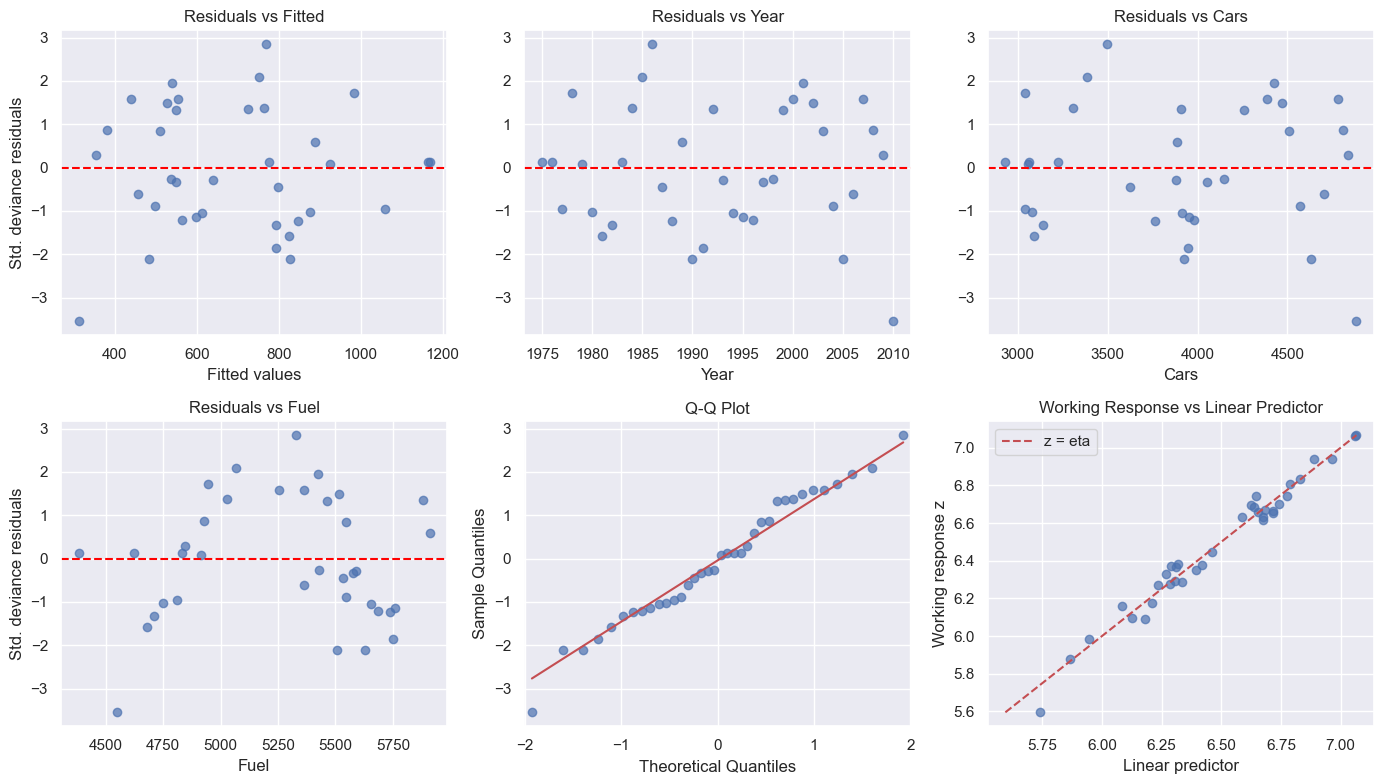

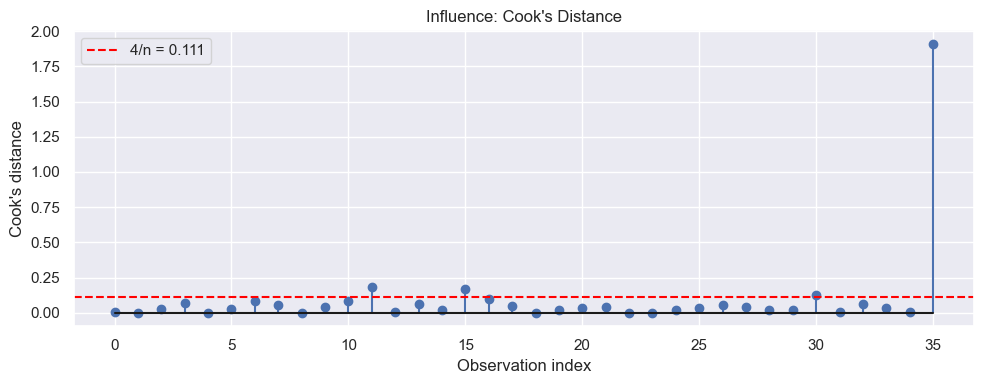

In [126]:
# Best model based on BIC — update best_model if needed
best_model = model3

fitted = best_model.fittedvalues
influence = best_model.get_influence()
hat = influence.hat_matrix_diag
std_dev_resid = best_model.resid_deviance / np.sqrt(1 - hat)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Residuals vs Fitted
axes[0, 0].scatter(fitted, std_dev_resid, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Residuals vs Year
axes[0, 1].scatter(cars['Year'], std_dev_resid, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_title('Residuals vs Year')

# Residuals vs Cars
axes[0, 2].scatter(cars['Cars'], std_dev_resid, alpha=0.7)
axes[0, 2].axhline(0, color='red', linestyle='--')
axes[0, 2].set_xlabel('Cars')
axes[0, 2].set_title('Residuals vs Cars')

# Residuals vs Fuel
axes[1, 0].scatter(cars['Fuel'], std_dev_resid, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fuel')
axes[1, 0].set_ylabel('Std. deviance residuals')
axes[1, 0].set_title('Residuals vs Fuel')

# Q-Q plot
from statsmodels.graphics.gofplots import ProbPlot
ProbPlot(std_dev_resid).qqplot(line='s', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Q-Q Plot')

# Working response plot
eta_hat = best_model.predict(linear=True)
working_resid = best_model.resid_working
z = eta_hat + working_resid
axes[1, 2].scatter(eta_hat, z, alpha=0.7)
lims = [min(eta_hat.min(), z.min()), max(eta_hat.max(), z.max())]
axes[1, 2].plot(lims, lims, 'r--', label='z = eta')
axes[1, 2].set_xlabel('Linear predictor')
axes[1, 2].set_ylabel('Working response z')
axes[1, 2].set_title('Working Response vs Linear Predictor')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Cook's distance separately
cooks = influence.cooks_distance[0]
fig2, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(len(cooks)), cooks, markerfmt='bo', linefmt='b-', basefmt='k-')
ax.axhline(4 / len(cooks), color='red', linestyle='--', label=f'4/n = {4/len(cooks):.3f}')
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.set_title("Influence: Cook's Distance")
ax.legend()
plt.tight_layout()
plt.show()


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       30
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -175.25
Date:                 st, 08 dub 2026   Deviance:                       50.889
Time:                        14:37:15   Pearson chi2:                     50.9
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      158.9604      8.592     18.501   

/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


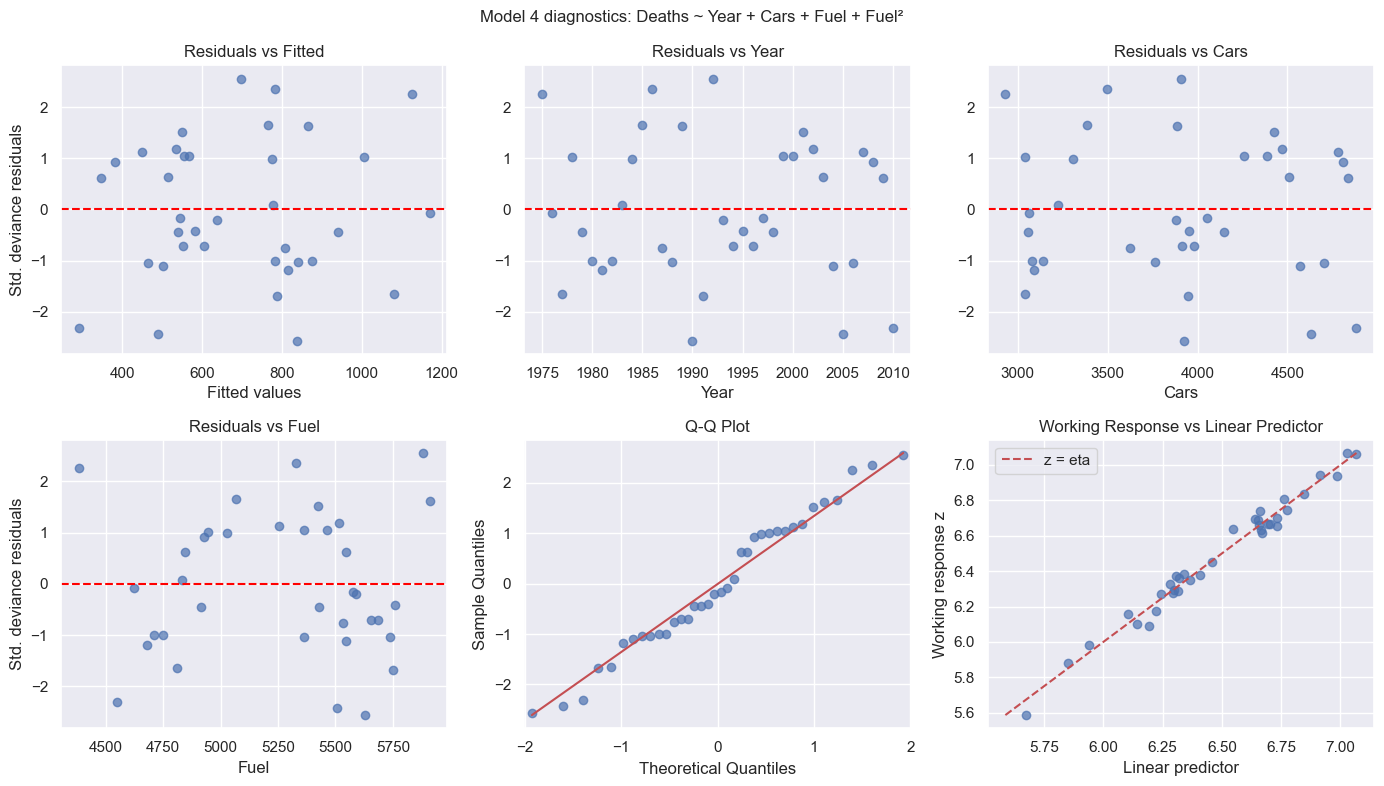

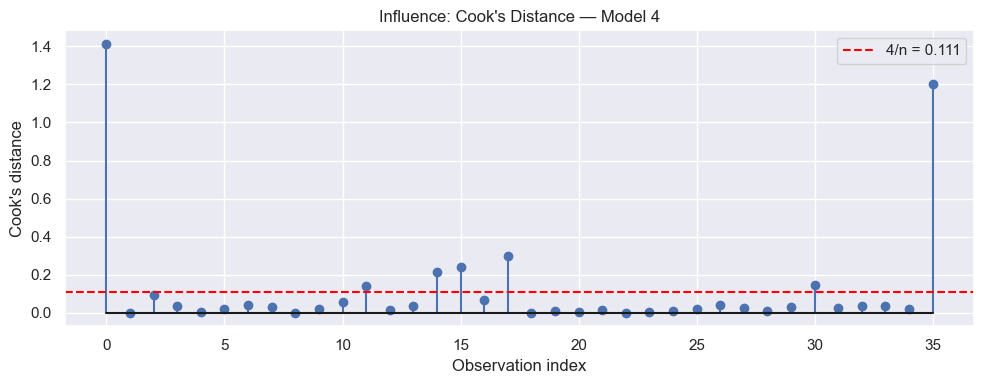

In [127]:
# Model 4: quadratic Fuel term
model4 = smf.glm(
    formula='Deaths ~ Year + Cars + Fuel + I(Fuel**2) + Fuel:Cars',
    data=cars,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print(model4.summary())
print(f"\nBIC srovnání:")
print(f"  Model 3 (Cars * Fuel):        BIC = {model3.bic:.2f}")
print(f"  Model 4 (Fuel + Fuel^2):      BIC = {model4.bic:.2f}")

# --- Diagnostics ---
fitted = model4.fittedvalues
influence = model4.get_influence()
hat = influence.hat_matrix_diag
std_dev_resid = model4.resid_deviance / np.sqrt(1 - hat)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Model 4 diagnostics: Deaths ~ Year + Cars + Fuel + Fuel²', fontsize=12)

axes[0, 0].scatter(fitted, std_dev_resid, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

axes[0, 1].scatter(cars['Year'], std_dev_resid, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_title('Residuals vs Year')

axes[0, 2].scatter(cars['Cars'], std_dev_resid, alpha=0.7)
axes[0, 2].axhline(0, color='red', linestyle='--')
axes[0, 2].set_xlabel('Cars')
axes[0, 2].set_title('Residuals vs Cars')

axes[1, 0].scatter(cars['Fuel'], std_dev_resid, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fuel')
axes[1, 0].set_ylabel('Std. deviance residuals')
axes[1, 0].set_title('Residuals vs Fuel')

from statsmodels.graphics.gofplots import ProbPlot
ProbPlot(std_dev_resid).qqplot(line='s', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Q-Q Plot')

eta_hat = model4.predict(linear=True)
z = eta_hat + model4.resid_working
axes[1, 2].scatter(eta_hat, z, alpha=0.7)
lims = [min(eta_hat.min(), z.min()), max(eta_hat.max(), z.max())]
axes[1, 2].plot(lims, lims, 'r--', label='z = eta')
axes[1, 2].set_xlabel('Linear predictor')
axes[1, 2].set_ylabel('Working response z')
axes[1, 2].set_title('Working Response vs Linear Predictor')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Cook's distance
cooks = influence.cooks_distance[0]
fig2, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(len(cooks)), cooks, markerfmt='bo', linefmt='b-', basefmt='k-')
ax.axhline(4 / len(cooks), color='red', linestyle='--', label=f'4/n = {4/len(cooks):.3f}')
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.set_title("Influence: Cook's Distance — Model 4")
ax.legend()
plt.tight_layout()
plt.show()


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       30
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -169.90
Date:                 st, 08 dub 2026   Deviance:                       40.203
Time:                        14:39:04   Pearson chi2:                     40.2
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           157.5988      8.34

/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
/Users/ruslanguliev/Desktop/ZLMA/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


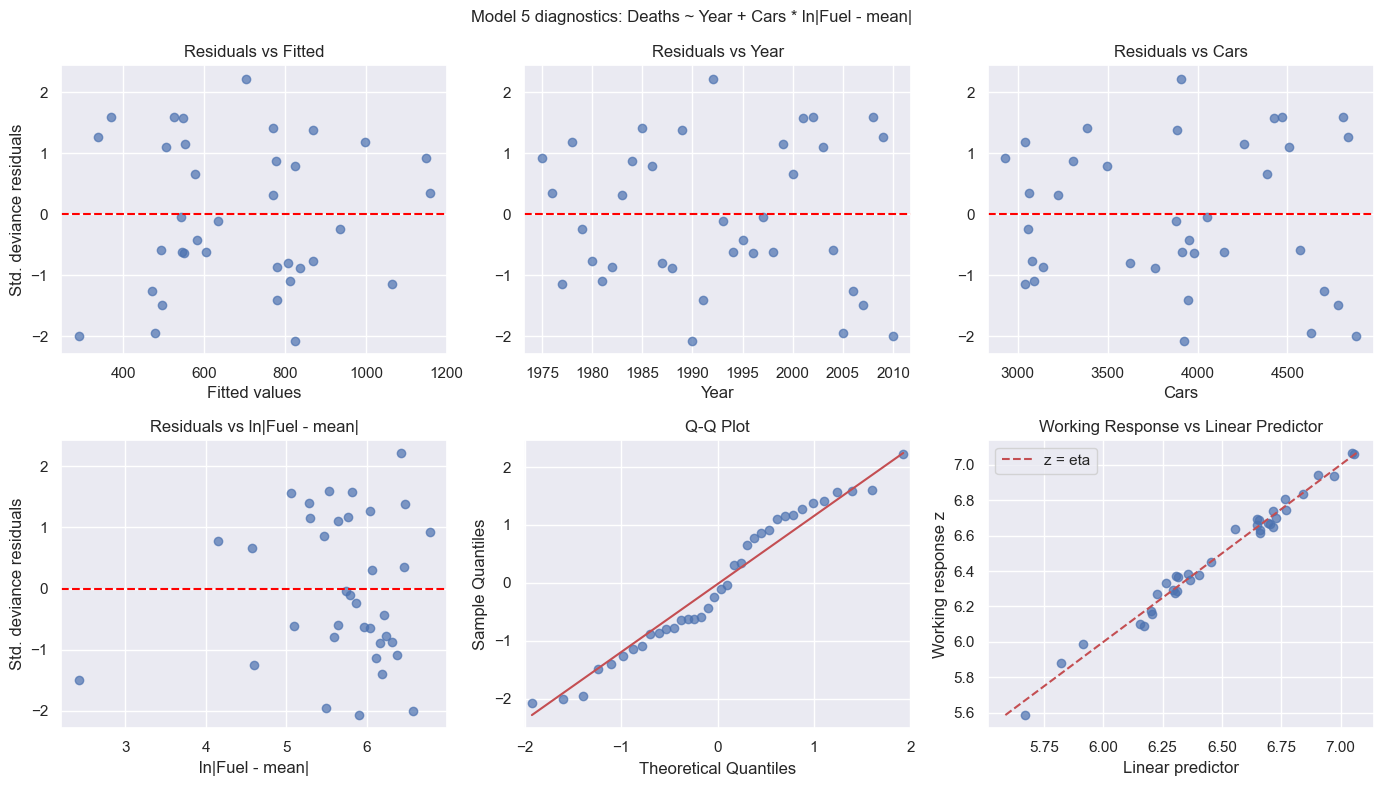

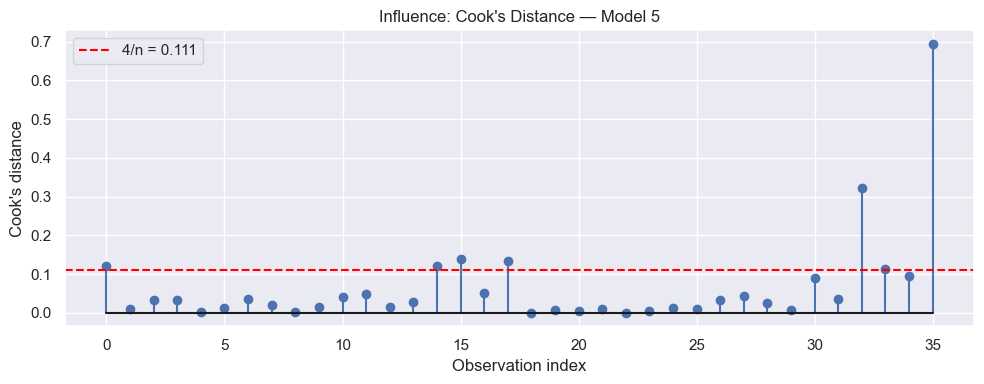

In [132]:
# Model 5: ln(|Fuel - Fuel_mean|) transformation
fuel_mean = cars['Fuel'].mean()
cars['Fuel_centered_log'] = np.log(np.abs(cars['Fuel'] - fuel_mean))

model5 = smf.glm(
    formula='Deaths ~ Year + Cars + Fuel + Cars:Fuel + Fuel_centered_log',
    data=cars,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print(model5.summary())
print(f"\nBIC srovnání:")
print(f"  Model 3 (Cars * Fuel):                 BIC = {model3.bic:.2f}")
print(f"  Model 4 (Fuel + Fuel^2):               BIC = {model4.bic:.2f}")
print(f"  Model 5 (Cars * ln|Fuel - mean|):      BIC = {model5.bic:.2f}")

# --- Diagnostics ---
fitted = model5.fittedvalues
influence = model5.get_influence()
hat = influence.hat_matrix_diag
std_dev_resid = model5.resid_deviance / np.sqrt(1 - hat)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Model 5 diagnostics: Deaths ~ Year + Cars * ln|Fuel - mean|', fontsize=12)

axes[0, 0].scatter(fitted, std_dev_resid, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Std. deviance residuals')
axes[0, 0].set_title('Residuals vs Fitted')

axes[0, 1].scatter(cars['Year'], std_dev_resid, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_title('Residuals vs Year')

axes[0, 2].scatter(cars['Cars'], std_dev_resid, alpha=0.7)
axes[0, 2].axhline(0, color='red', linestyle='--')
axes[0, 2].set_xlabel('Cars')
axes[0, 2].set_title('Residuals vs Cars')

axes[1, 0].scatter(cars['Fuel_centered_log'], std_dev_resid, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('ln|Fuel - mean|')
axes[1, 0].set_ylabel('Std. deviance residuals')
axes[1, 0].set_title('Residuals vs ln|Fuel - mean|')

from statsmodels.graphics.gofplots import ProbPlot
ProbPlot(std_dev_resid).qqplot(line='s', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Q-Q Plot')

eta_hat = model5.predict(linear=True)
z = eta_hat + model5.resid_working
axes[1, 2].scatter(eta_hat, z, alpha=0.7)
lims = [min(eta_hat.min(), z.min()), max(eta_hat.max(), z.max())]
axes[1, 2].plot(lims, lims, 'r--', label='z = eta')
axes[1, 2].set_xlabel('Linear predictor')
axes[1, 2].set_ylabel('Working response z')
axes[1, 2].set_title('Working Response vs Linear Predictor')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Cook's distance
cooks = influence.cooks_distance[0]
fig2, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(len(cooks)), cooks, markerfmt='bo', linefmt='b-', basefmt='k-')
ax.axhline(4 / len(cooks), color='red', linestyle='--', label=f'4/n = {4/len(cooks):.3f}')
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.set_title("Influence: Cook's Distance — Model 5")
ax.legend()
plt.tight_layout()
plt.show()


---
## Appendix: R Comparison

For reference, here is how Model 3 diagnostics look in R:

In [129]:
%%R
trees_m3 <- glm(Volume ~ log(Girth) + log(Height),
                family = Gamma(link = "log"), data = trees)
summary(trees_m3)


Call:
glm(formula = Volume ~ log(Girth) + log(Height), family = Gamma(link = "log"), 
    data = trees)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.69111    0.78784  -8.493 3.11e-09 ***
log(Girth)   1.98041    0.07389  26.802  < 2e-16 ***
log(Height)  1.13288    0.20138   5.625 5.04e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Gamma family taken to be 0.006427286)

    Null deviance: 8.31720  on 30  degrees of freedom
Residual deviance: 0.18352  on 28  degrees of freedom
AIC: 139.9

Number of Fisher Scoring iterations: 3



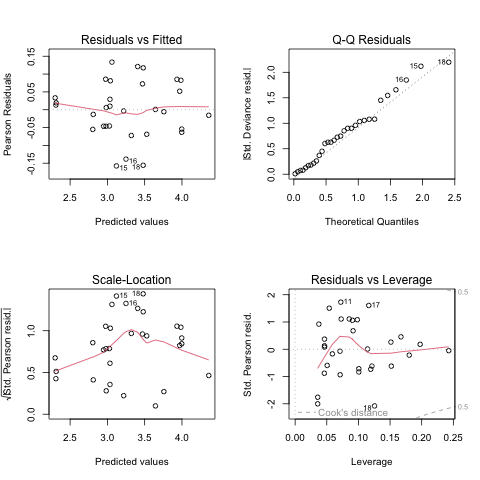

In [130]:
%%R
par(mfrow = c(2, 2))
plot(trees_m3)

In [131]:
%%R
# Influence measures
im <- influence.measures(trees_m3)
summary(im)

Potentially influential observations of
	 glm(formula = Volume ~ log(Girth) + log(Height), family = Gamma(link = "log"),      data = trees) :

   dfb.1_ dfb.l(G) dfb.l(H) dffit cov.r   cook.d hat  
3   0.07  -0.02    -0.05     0.09  1.39_*  0.00   0.20
20 -0.02  -0.02     0.03    -0.03  1.47_*  0.00   0.24
31  0.04  -0.06    -0.03    -0.10  1.35_*  0.00   0.18
